# 1. BUSINESS CASE & PROBLEM DEFINITION

## 1.2 BUSINESS UNDERSTANDING  
La rentabilidad de un hotel depende directamente del nivel de ocupación real, es decir, del número de reservas que finalmente se materializan. Sin embargo, una proporción significativa de las reservas termina en cancelaciones. Cuando estas cancelaciones no se compensan con nuevas reservas en un periodo razonable, el hotel pierde ingresos y reduce su eficiencia operativa.

El objetivo de negocio es anticipar qué reservas tienen mayor probabilidad de cancelarse para permitir al hotel tomar decisiones más inteligentes. Con esta información, el equipo de Revenue Management y el departamento de Reservas podrán:

- aplicar estrategias de overbooking controlado,

- ajustar precios de forma dinámica,

- mejorar la comunicación con clientes de alto riesgo,

- adaptar las políticas de cancelación según el perfil de la reserva.

El modelo permitirá minimizar el impacto negativo de las cancelaciones, optimizar la ocupación y mejorar la rentabilidad sin perjudicar la experiencia del cliente.

## 1.2 ML OBJECTIVE
El problema se traduce en un objetivo de Machine Learning claro:

**Tipo de problema:** *Clasificación binaria*

***Variable target:** *is_canceled*

**Clases:**

- 0 → Reserva que llega a término

- 1 → Reserva cancelada

Métricas adecuadas según la guía
Dado que el dataset está desbalanceado, las métricas recomendadas son:
F1-score, Recall (especialmente importante si queremos detectar cancelaciones), Precision, ROC-AUC

Dado que el coste de no detectar una cancelación es mayor que el de una falsa alarma, se priorizará el Recall y el F1-score sobre el Accuracy.

## 1.3 ACTION PLAN

En función de la predicción del modelo:

- Si la reserva tiene alta probabilidad de cancelarse:

- activar estrategias de overbooking controlado,

- enviar comunicaciones preventivas al cliente,

- ajustar precios dinámicamente,

- aplicar políticas de cancelación más estrictas.

Si la probabilidad es baja:

- mantener condiciones estándar,

- priorizar la reserva en caso de alta demanda.

**Umbral mínimo de rendimiento**

El modelo se considerará útil si alcanza un ROC-AUC ≥ 0.75 y un Recall ≥ 0.70 en la clase de cancelación.

**Datos y licencia**
Dataset: Hotel Booking Demand (Kaggle)
Accesible: Sí
Licencia: Open Data (uso permitido para proyectos educativos)

# 2. DATA UNDERSTANDING

## 2.1 FIRST LOOK

In [131]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from lightgbm import LGBMClassifier

from scipy.stats import chi2_contingency, randint, uniform

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, classification_report, 
                             ConfusionMatrixDisplay, RocCurveDisplay)

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier


In [132]:
df = pd.read_csv('src/data_sample/hotel_bookings.csv')

In [133]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Target `is_canceled`  valores 1 cuando la reserva es cancelada y 0 cuando no

In [134]:
print(f"Shape: {df.shape}")
df.info()
df.describe(include='all')
(df.isnull().mean() * 100).sort_values(ascending=False).round(1)

Shape: (119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 

company                           94.3
agent                             13.7
country                            0.4
children                           0.0
arrival_date_month                 0.0
arrival_date_week_number           0.0
hotel                              0.0
is_canceled                        0.0
stays_in_weekend_nights            0.0
arrival_date_day_of_month          0.0
adults                             0.0
stays_in_week_nights               0.0
babies                             0.0
meal                               0.0
lead_time                          0.0
arrival_date_year                  0.0
distribution_channel               0.0
market_segment                     0.0
previous_bookings_not_canceled     0.0
is_repeated_guest                  0.0
reserved_room_type                 0.0
assigned_room_type                 0.0
booking_changes                    0.0
previous_cancellations             0.0
deposit_type                       0.0
days_in_waiting_list     

Porcentaje de nulos por columna:  
children = 0.003%  
country = 0.409%  
agent = 13.686%  No es un porcentaje de nulos alto, por lo que se puede imputar valores 'unknown' o valorar alguna estrategia para eliminar los valores nulos
company = 94.306%  El procentaje de nulos es tan alto que hace que la variable no aporte ningúna información. Se valorará descartarla

## 2.2 DATA DICTIONARY

#### Importancia preliminar de las variables (Valoración inicial)

La columna `reservation_status` contiene valores equivalentes al target.  

Por otro lado, la columna `reservation_status_date` representa la fecha en la que se registró el estado final de la reserva (cancelación, check-out o no-show). Esta información solo existe después de que la reserva ya ha concluido, por lo que no está disponible en el momento en que queremos predecir si una reserva será cancelada. Usarla introduciría fuga de información (data leakage), ya que el modelo aprendería patrones derivados del resultado final de la reserva.  

Aquellas columnas cuyo porcentaje de nulos sobrepasa el 80% se descartarán: se guardará en la variable `descartable_null`

In [135]:
df[['reservation_status', 'is_canceled']].groupby('reservation_status').mean()

,is_canceled
reservation_status,
Canceled,1.0
Check-Out,0.0
No-Show,1.0


In [136]:
target = 'is_canceled'
leakage_cols = ['reservation_status', 'reservation_status_date']
null_pct = (df.isnull().mean() * 100).round(1)
descartable_null = null_pct > 80
descartable_manual = df.columns.isin(leakage_cols)

descartable = descartable_null | descartable_manual

data_dict = pd.DataFrame({
    'columna': df.columns,
    'dtype': df.dtypes.values,
    'nulos_pct': null_pct.values,
    'unicos': df.nunique().values,
    'card_relativa': (df.nunique() / len(df)).round(3).values,
    'ejemplo': [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else None for c in df.columns],
    'valor_modelo': [
        'alta' if col in ['lead_time','adr','deposit_type','previous_cancellations'] else
        'media' if col in ['agent','market_segment','customer_type'] else
        'leakage' if col in ['reservation_status','reservation_status_date'] else
        'irrelevante' if col in ['arrival_date_week_number'] else
        'pendiente'
        for col in df.columns
    ],
    'descartable': descartable.values
})
data_dict

,columna,dtype,nulos_pct,unicos,card_relativa,ejemplo,valor_modelo,descartable
0,hotel,object,0.0,2,0.000,Resort Hotel,pendiente,False
1,is_canceled,int64,0.0,2,0.000,0,pendiente,False
2,lead_time,int64,0.0,479,0.004,342,alta,False
3,arrival_date_year,int64,0.0,3,0.000,2015,pendiente,False
4,arrival_date_month,object,0.0,12,0.000,July,pendiente,False
5,arrival_date_week_number,int64,0.0,53,0.000,27,irrelevante,False
6,arrival_date_day_of_month,int64,0.0,31,0.000,1,pendiente,False
7,stays_in_weekend_nights,int64,0.0,17,0.000,0,pendiente,False
8,stays_in_week_nights,int64,0.0,35,0.000,0,pendiente,False
9,adults,int64,0.0,14,0.000,2,pendiente,False


**Variables con alta aportación esperada**  
- `lead_time`: Las reservas con mucha antelación se suelen cancelar más  
- `adr`: 'Tarifa media Diaria' El precio influye en la probabiliad de cancelación. Se puede crear una variable `adr_per_person` dividiendo `adr`entre el número total de huéspedes de la reserva.
- `deposit_type`: Los depósitos no reembonsables reducen cancelaciones
- `previous_cancellations`: Refleja comportamiento histórico del cliente.
- `previous_bookings_not_canceled`: Es un indicador de estabilidad en reservas anteriores.
- `total_of_special_requests`: Los clientes con más requisitos cancelan menos  
- `booking_changes`: Número de modificaciones de la reserva, hasta el check-in o cancelación. Un mayor número de modificaciones puede indicar inestabilidad en la reserva.

**Variables con aportación media**
- `agent`: Algunas agencias tienen tasas de cancelación distintas
- `market_segments`: Ciertos segmentos (TA, TO) muestran patrones distintos de cancelación.
- `customer_type`: Familias, parejas o grupos tiene comportamientos distintos
- `hotel`: El tipo de hotel puede influir en la probabilidad de cancelación.
: Habrá que valorarl en el EDA si se aprecia un patrón respecto al target
- `stays_in_weekend_nights` y `stays_in_week_nights`: Estancia en noches de fin de semana y estancia en noches en día laborable. En la fase de feature Engineering se puede crear una columna que englobe estas dos variables para obtener el número total de noches por reserva.
- `adults`, `children` y `babies`: Número de adultos, niños y bebés en la reserva. Puede ser últil de cara a la fase de Feature Engineering crear una variable is_family en la que se valore si en la reserva hay niños o bebés ya que normalmente suelen ser reservas más estables y con menos tendencia a cancelaciones.
- `country`:  Aporta valor si la cardinalidad no es excesiva (en nuestro caso es de un 0.001) y existe suficiente representación por país. No es una variable fuerte pero tampoco es irrelevante. La aportación depende de la distribución por país; los países con suficiente representación aportan información, mientras que los minoritarios no.
- `is_repeated_guest`: La reserva ha sido hecha por una persona que ha reservado con anterioridad. Los clientes que repiten tienden a cancelar menos.

**Variable con aportación baja o redundante**
- `assigned_room_type` y `reserved_room_type`: Código que indica el tipo de habitación asignada en la reserva y reservada, en ocasiones pueden diferir. Suelen ser redundantes porque el tipo asignado depende del reservado. No aportan información sobre la cancelación y están altamente correlacionadas.
- `meal`: El régimien aliminticio no muestra relación clara con la cancelación.
- `required_car_parking_spaces`: Número de plazas de aparcamiento solicitadas por el huésped. Baja aportación
- `arrival_date_week_number`: Poca relación con el target según el EDA
- `arrival_date_year`: Casi no aporta variabilidad
- `arrival_date_day_of_month`: No muestra relación con el target
- `arrival_date_month`: Debido a la estacionalidad, en verano hay más reservas, pero no hay un patrón claro en prpoporción de cancelaciones. El ligero aumento en primavera/verano se debe más al volumen de reservas que a una modificación del comportamiento

**Variables descartadas**
- `company`: >80% nulos -> no aporta valor
- `reservation_status`: Information leakage (coincide con el target)  
- `reservation_status_date`: Information leakage. Previamente explicado


## 2.3 TRAIN-TEST SPLIT

In [137]:
TARGET = 'is_canceled'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y  # solo en clasificación
)

X_train_raw, X_test_raw = X_train.copy(), X_test.copy()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")



Train: (95512, 31), Test: (23878, 31)


# 3. EDA DIRIGIDO AL MODELADO

## 3.1 TARGET ANALYSIS

En la gráfica de distribución del target vemos que es de un 37% de cancelaciones y un 63% de reservas no canceladas.  
Si bien es verdad que no es un desbalance severo, si se puede considerar que es un desbalanceo moderado de manera que:  
- Accuracy no sea una métrica fiable,
- SMOTE podría ayudar pero no es obligatorio
- Hacer un Stratify en el split es altamente recomendable (ha se hizo en el split train test)

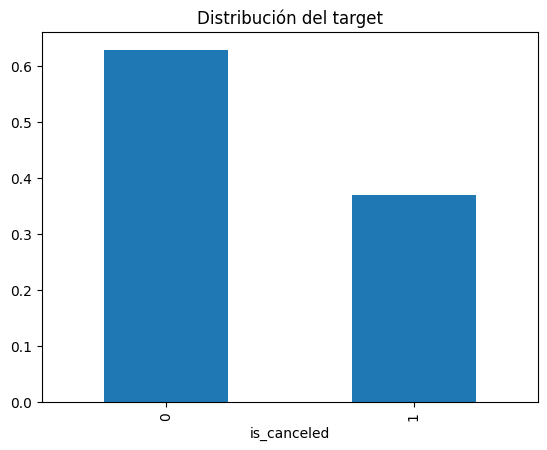

Skewness: 0.54


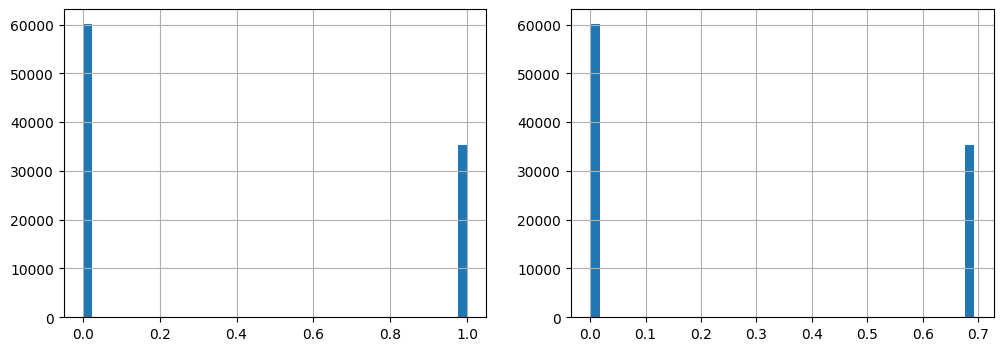

In [138]:
# Clasificación: balanceo de clases
y_train.value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución del target'); plt.show()

# Regresión: distribución y asimetría
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.hist(bins=40, ax=axes[0])
np.log1p(y_train).hist(bins=40, ax=axes[1])
print(f"Skewness: {y_train.skew():.2f}")

## 3.2 FEATURE - TARGET RELATIONSHIP

Antes de hacer el análisis multivariante con el target excluimos de las features a analaizar las columnas consideradas poco importantes y sobre todo las que puedan producir leakage como se puede ver en el apartado 2.2

In [139]:
cols_descartables = ['company', 'reservation_status', 'reservation_status_date']

### Numéricas vs. target para problemas de clasifiicación: distribución por clase

In [140]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in cols_descartables]
num_cols


['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

**Correlación de Pearson** entre cada variable numérica y el target. Esta métrica permite identificar qué variables presentan una relación lineal más fuerte con la cancelación y, por tanto, pueden aportar mayor señal al modelo.

In [141]:
corr = pd.concat([X_train[num_cols], y_train], axis=1).corr()[y_train.name].sort_values()
corr


total_of_special_requests        -0.236955
required_car_parking_spaces      -0.194639
booking_changes                  -0.141886
is_repeated_guest                -0.086247
agent                            -0.079114
previous_bookings_not_canceled   -0.057203
babies                           -0.030659
arrival_date_day_of_month        -0.006720
stays_in_weekend_nights           0.000977
children                          0.005648
arrival_date_week_number          0.007270
arrival_date_year                 0.017537
stays_in_week_nights              0.025650
adr                               0.046147
days_in_waiting_list              0.053600
adults                            0.057953
previous_cancellations            0.111525
lead_time                         0.293034
is_canceled                       1.000000
Name: is_canceled, dtype: float64

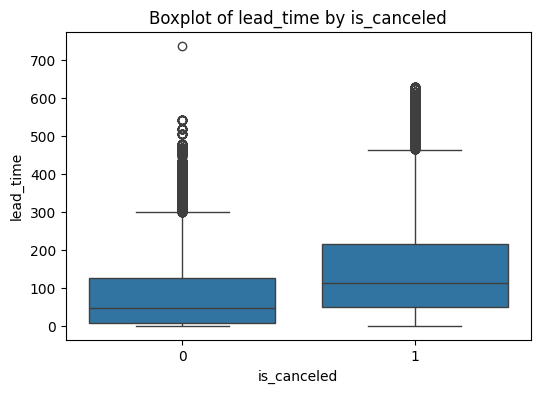

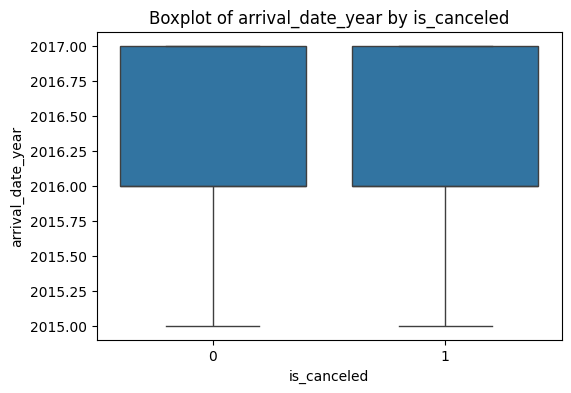

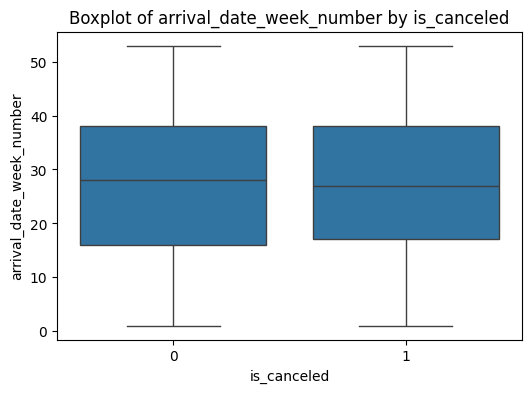

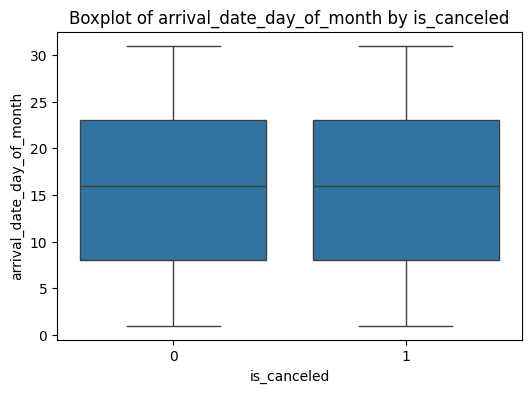

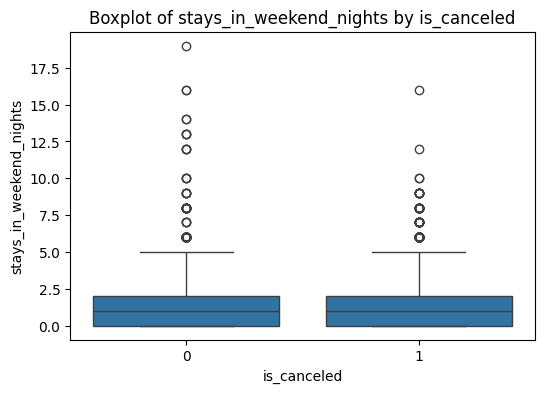

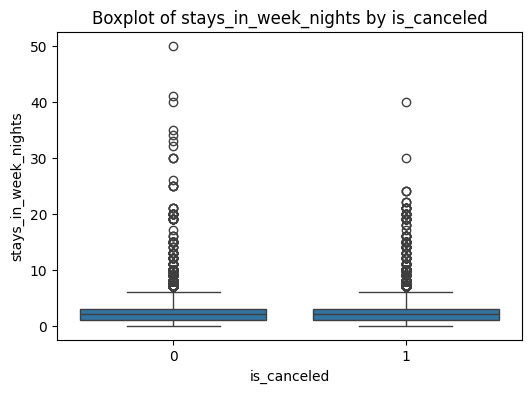

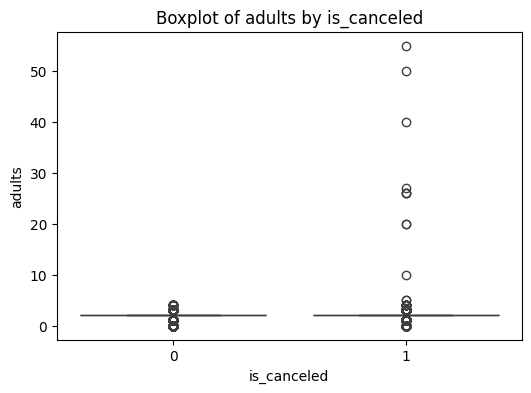

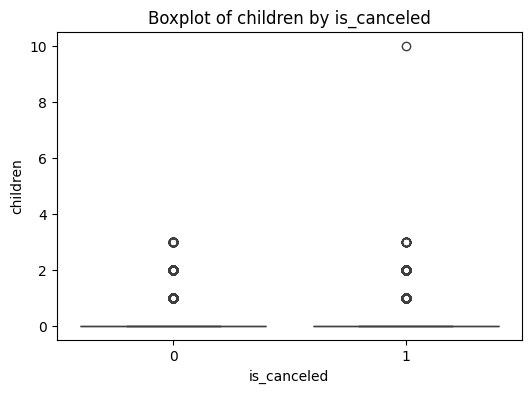

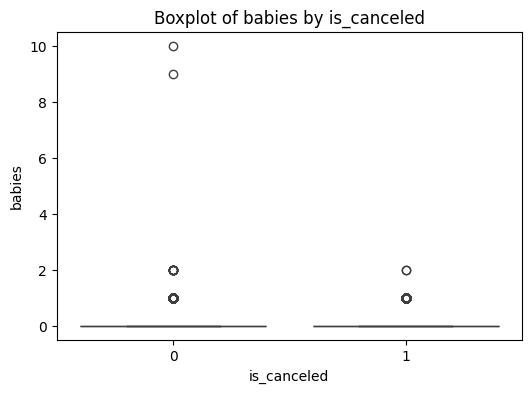

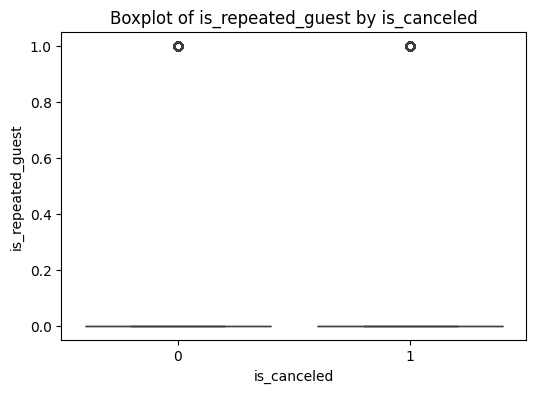

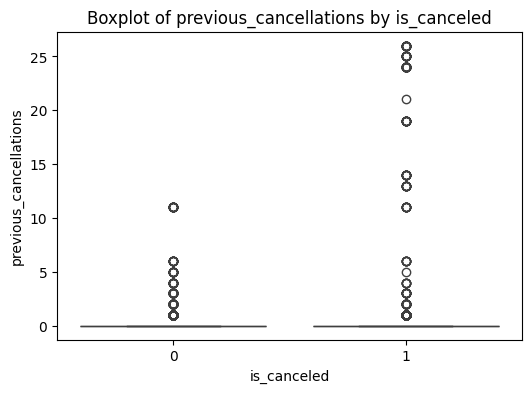

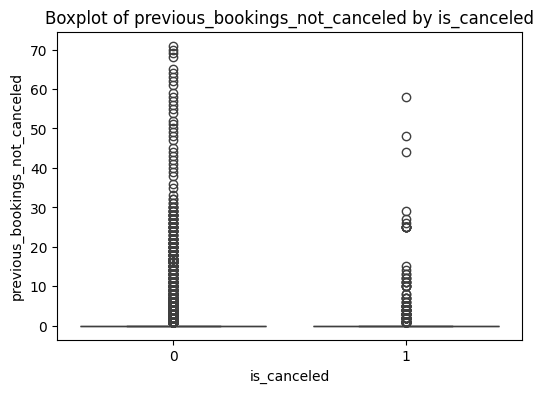

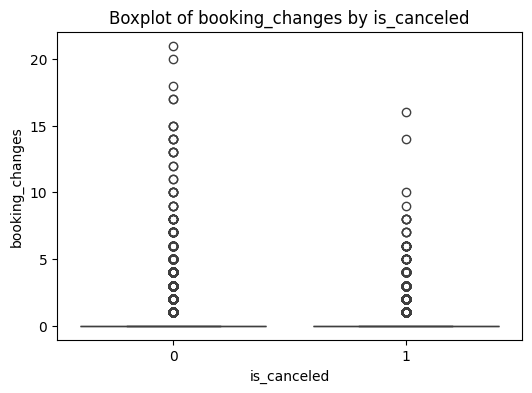

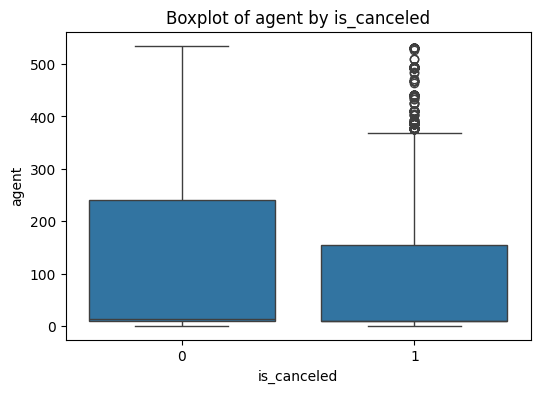

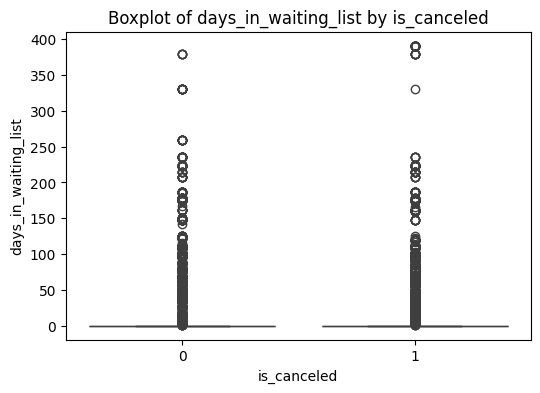

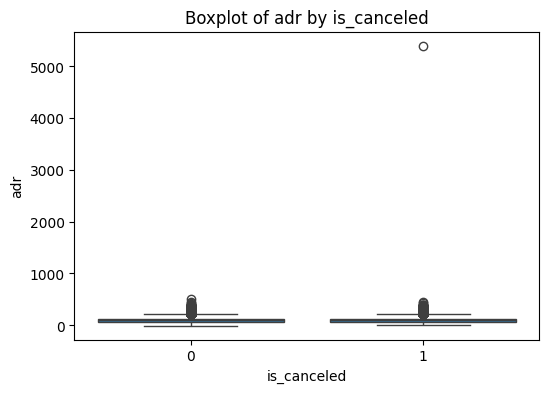

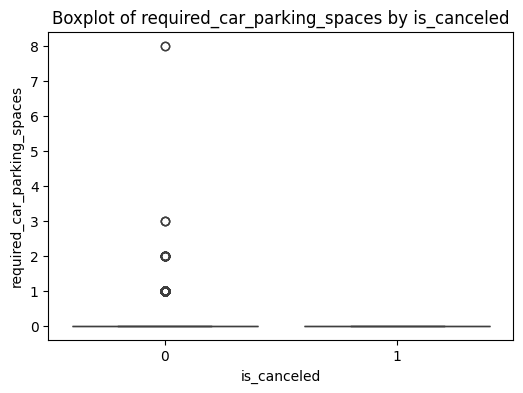

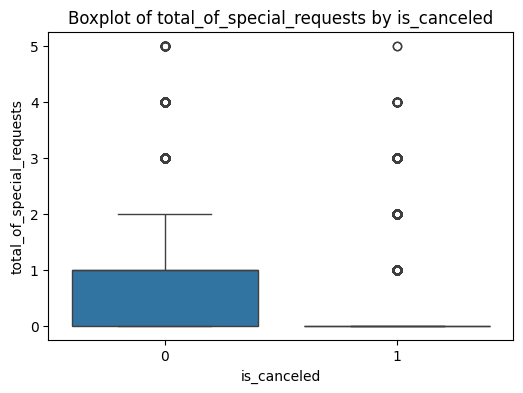

In [142]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=X_train.join(y_train), x=TARGET, y=col)
    plt.title(f'Boxplot of {col} by {TARGET}')
    plt.show()


Consierando el estadístico Pearson y los boxplot podemos identificar qué variables presentan una relación lineal más fuerte con la cancelación:
- `lead_time`: Los outliers son esperables (reservas hechas con muchísima antelación). Amayor lead_time, mayor robabilidad de cancelación. Es una variable muy fuerte para el modelo. Además tiene un importante coeficiente de correlación **(0.29)**
- `adults`, `children`y `babies`: Por separado tienen una correlación baja, pero viaualmente se ve que las reservas con ninños o bebés tienden a sufrir menos cancelaciones. Por tanto, crear una columna is_family que indique si la reserva incluye niños y/o bebés, es una transformación útil.
- `is_repeated_guest`: Los clientes que ya han reservado previamente suelen cancelar menos.
- `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month`: Se trata de variables de fecha que además no aportan mucho respecto al target. No muestran patrones claros de cancelación ni variabilidad relevante. Tienen coeficientes de correlación con la target muy bajos.
- `stays_in_weekend_nights`, `stays_in_week_nights`. Pueden ser más informativa si se combinan en una columna `total_nights` que capture mejor la duración de la estancia. Reduce dimensionalidad sin perder información.
- `previous_cancellations`: Las reservas que han sufrido cancelaciones previas, tienen a ser canceladas. Tiene un 0.1 de coeficiente de correlación media.
- `previous_bookings_not_canceled`: En esta variable sin embargo cuantas más reservas previas no han sido canceladas, la tendencia es a no cancelar
- `booking_changes`: Las reservas con más cambios suelen ser más inestables, lo que puede aumentar la probabilidad de cancelación.
- `agent`
- `days_in_waiting_list`: No suele mostrar relación fuerte con cancelación; aporta señal baja o nula.
- `adr`: El precio influye en la cancelación: tarifas más altas pueden asociarse a mayor probabilidad de cancelar. Variable fuerte
- `required_car_parking_spaces`: No muestra relación clara con cancelación. Baja aportación
- `total_of_special_requests`: Presenta una correlación negativa con el target **(-0.24)**, lo que indica que las reservas con más solicitudes especiales tienden a cancelarse menos.

### Categóricas vs. target

In [143]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in cols_descartables]
cat_cols

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type']

El estadístico **chi‑cuadrado** aumenta automáticamente con el tamaño del dataset y con el número de categorías, lo que hace que no sea adecuado para comparar la fuerza de asociación entre distintas variables categóricas. Para resolver este problema se utiliza **Cramér’s** V, que normaliza el **chi‑cuadrado** dividiéndolo por el número total de observaciones y por el número de categorías. 
Esto produce un valor entre 0 y 1 que permite comparar variables categóricas entre sí y evaluar su aportación real al modelo.

In [144]:
# chi2 depende del tamaño del dataset, crece cuando el dataset es grande aunque la relación entre variables sea débil
# porque suma diferencias absolutas
# 0-0.1 relación muy débil, hasta 0.2 débil, 0.2-0-3 media y mayor de 0.3 fuerte

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in cat_cols:
    print(col, round(cramers_v(X_train[col], y_train), 3))

hotel 0.132
arrival_date_month 0.068
meal 0.05
country 0.362
market_segment 0.267
distribution_channel 0.176
reserved_room_type 0.074
assigned_room_type 0.203
deposit_type 0.483
customer_type 0.137


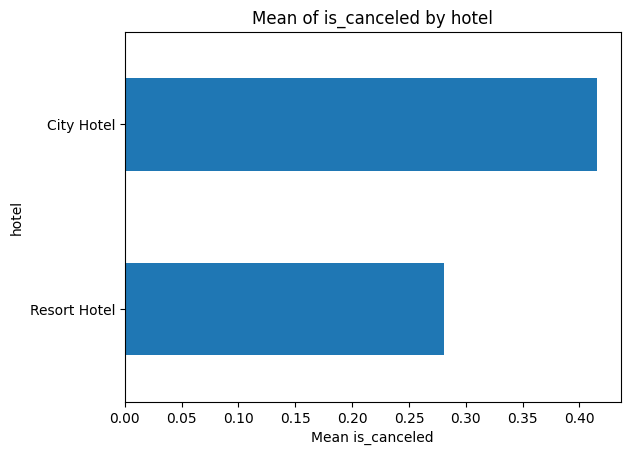

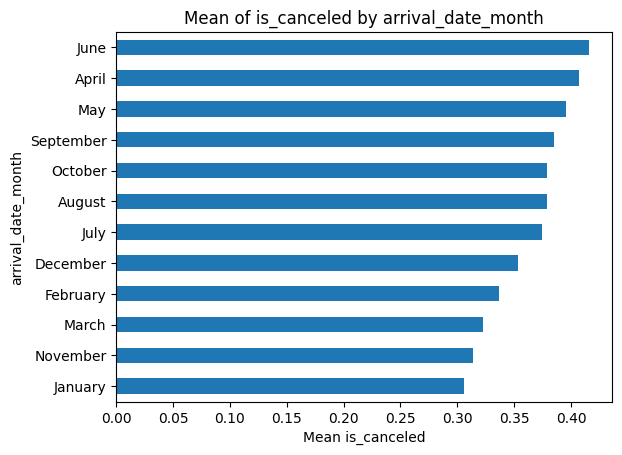

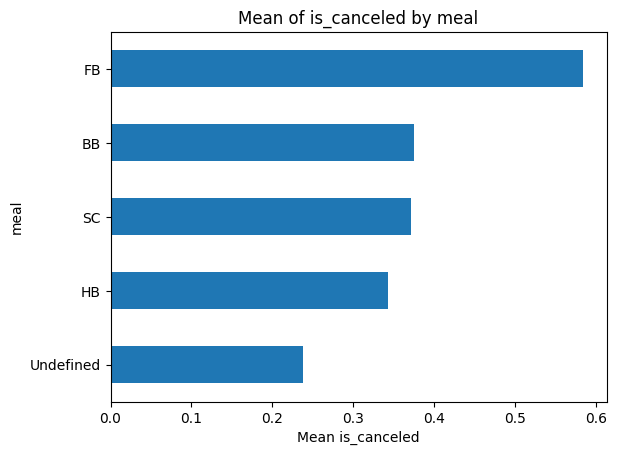

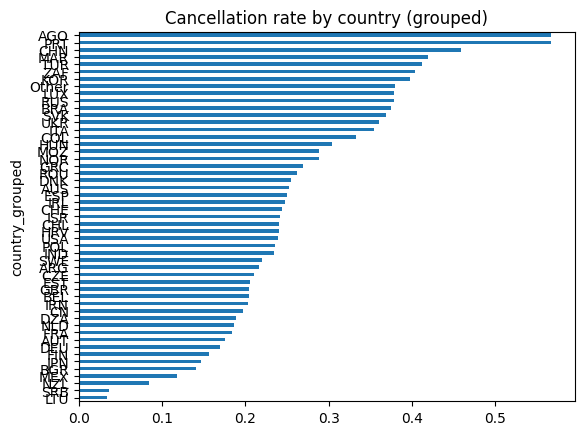

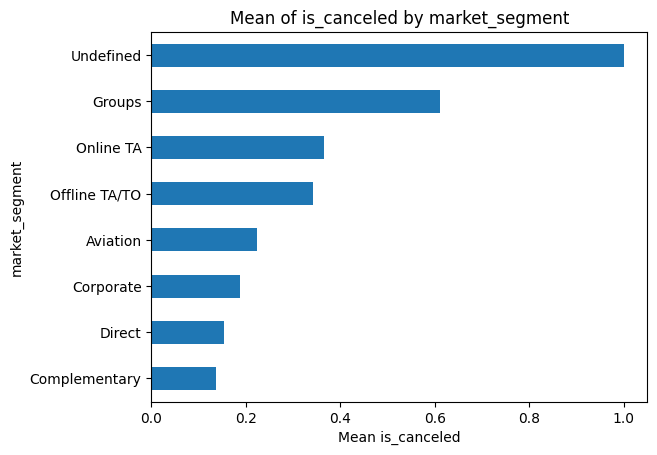

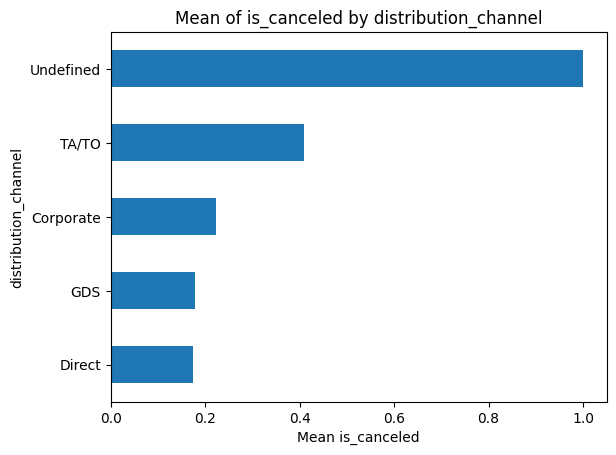

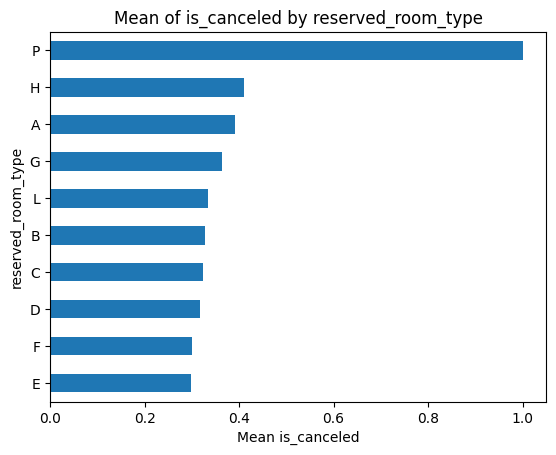

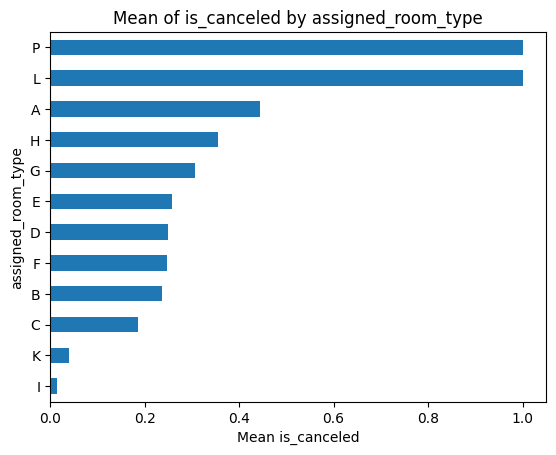

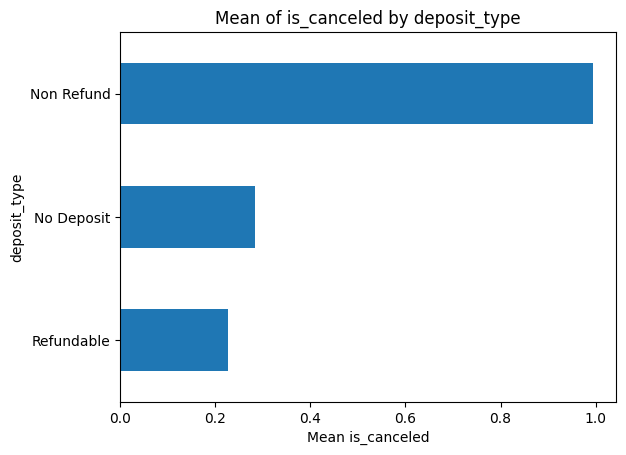

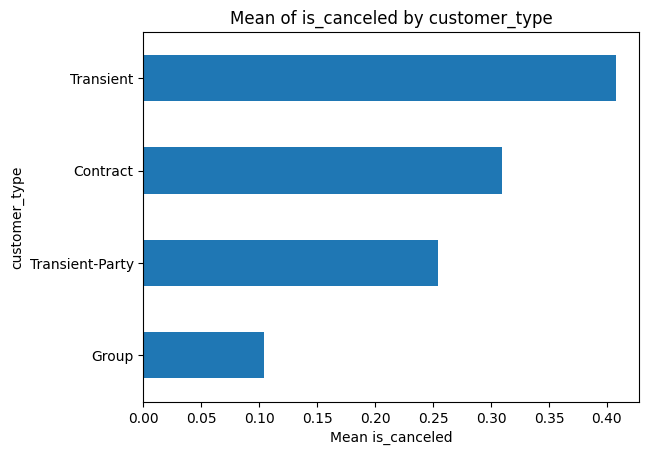

In [145]:
df_ct = X_train.join(y_train).copy()
country_counts = df_ct['country'].value_counts()

rare_countries = country_counts[country_counts < 50].index
df_ct['country_grouped'] = df_ct['country'].replace(rare_countries, 'Other')


for col in cat_cols:
    if col == 'country':
        df_ct.groupby('country_grouped')[TARGET].mean().sort_values().plot(kind='barh')
        plt.title('Cancellation rate by country (grouped)')
    else:
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_values().plot(kind='barh')
        plt.title(f'Mean of {TARGET} by {col}')
        plt.xlabel(f'Mean {TARGET}')
        plt.ylabel(col)
    plt.show()

A partir de la visualización de las variables categóricas frente al target y del análisis mediante Cramér’s V, se observa lo siguiente:

- `hotel`: **V = 0.132 (asociación débil-media)**: Las cancelaciones son menos frecuentes en los hoteles de vacaciones (Resort Hotel) que en los hoteles urbanos (City Hotel). Esto sugiere que los clientes que viajan por ocio tienden a cancelar menos que los que viajan por motivos laborales o estancias cortas. 
- `arrival_date_month`: **V = 0.068 (asociación débil)**: Se observa un ligero aumento de cancelaciones en primavera–verano. No parece un efecto especialmente marcado y podría estar influido por el incremento general de reservas en esos meses. 
- `meal`: **V = 0.050 (asociación muy débil)**: Aunque algunas modalidades como Full Board muestran más cancelaciones en la visualización, la fuerza de asociación es muy baja.
- `country`: **V = 0.362 (asociación media-fuerte)**: El país de origen influye claramente en la tasa de cancelación: algunos países presentan porcentajes significativamente más altos que otros. Debido a su alta cardinalidad, conviene agrupar países con pocas observaciones o trabajar solo con los más representativos. Es una variable con alta aportación potencial, pero requiere tratamiento previo.
- `market_segment` **V = 0.267 (asociación media)**: La forma de contratar la reserva influye en la probabilidad de cancelación. Además, la distribución de cancelaciones por segmento es similar a la observada en `distribution_channel` **V = 0.176 (asociación débil-media)**, lo que indica que ambas variables están relacionadas y reflejan patrones similares de comportamiento del cliente.
- `reserved_room_type` **V = 0.074 (asociación débil)**  y `assigned_room_type` **V = 0.203 (asociación media)**. `assigned_room_type` Tiene una asociación más fuerte que la habitación reservada, lo que sugiere que la asignación final refleja mejor el comportamiento del cliente o la política del hotel.
Es una variable más relevante que su equivalente “reservada”.
- `deposit_type` **V = 0.483 (asociación fuerte)**: Las reservas clasificadas como Non Refund muestran más cancelaciones, lo cual puede parecer contraintuitivo. Sin embargo, esta variable refleja la política del hotel, no necesariamente el comportamiento del cliente. Las tarifas Non Refund suelen ser más económicas y se reservan con mayor antelación, lo que atrae a clientes con menor compromiso. Por ello, esta variable es relevante para el modelo y está correlada con otras como `lead_time` (alto) y `market_segment`, que explican mejor este patrón.
- `customer_type` **V = 0.483 (asociación fuerte)**: El tipo de contrato también influye en la tasa de cancelación. Algunos perfiles de cliente muestran mayor estabilidad que otros, lo que convierte esta variable en un factor potencialmente relevante para el modelo.

### Temporales vs. target

Las variables temporales relacionadas con la fecha de llegada se han clasificado como de baja aportación porque, aunque podrían sugerir estacionalidad, el EDA muestra que no aportan señal predictiva relevante respecto a la cancelación.

In [146]:
temp_cols = [
    'arrival_date_year',
    'arrival_date_month',
    'arrival_date_week_number',
    'arrival_date_day_of_month'
]


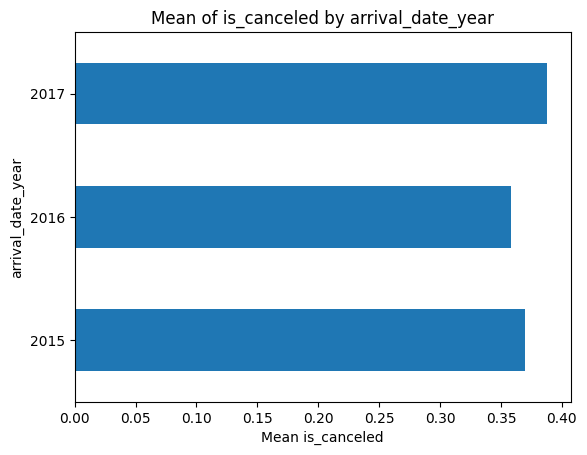

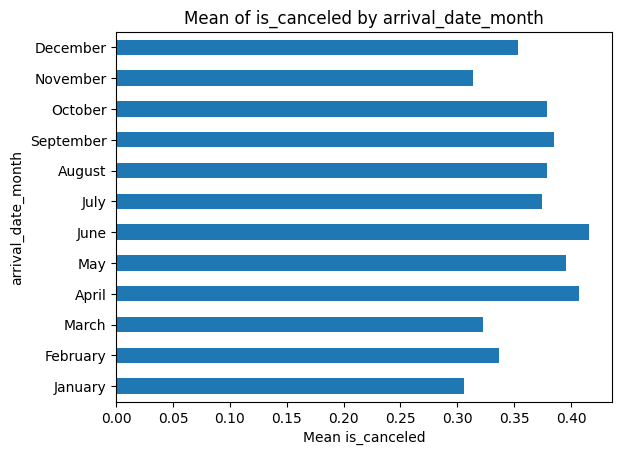

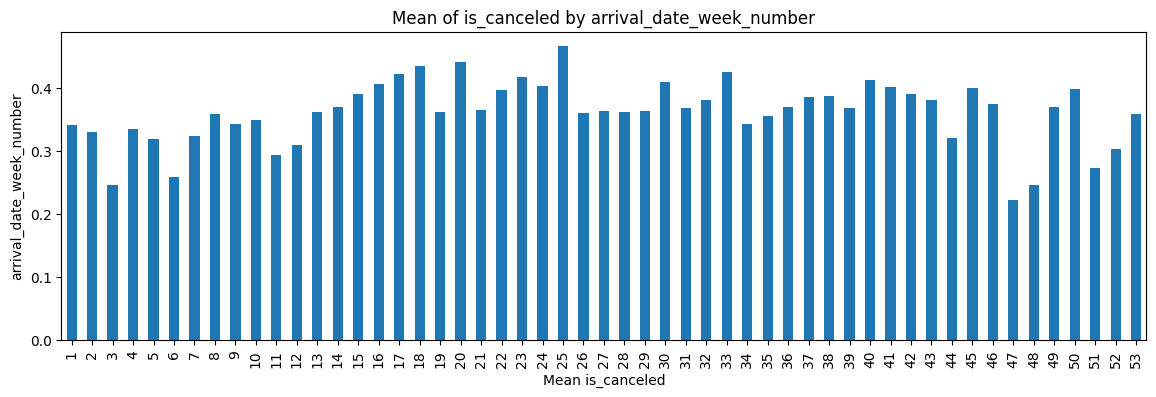

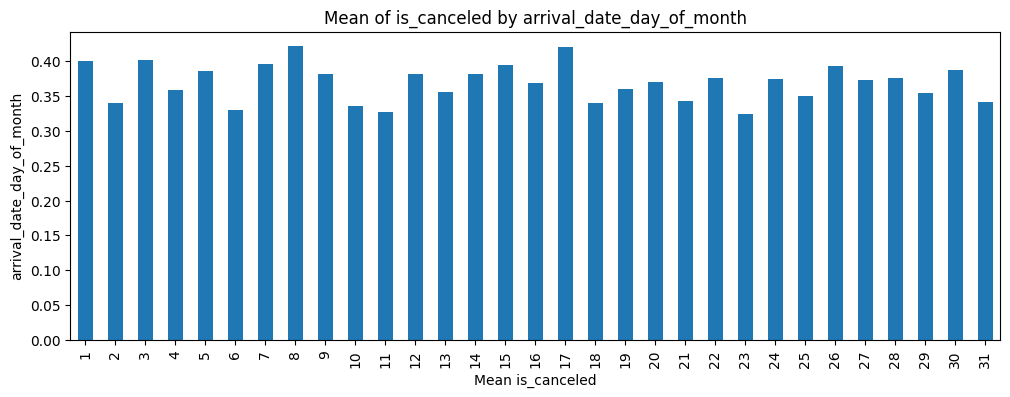

In [147]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

for col in temp_cols:    
    if col == 'arrival_date_month':
        X_train.join(y_train).groupby(col)[TARGET].mean().loc[month_order].plot(kind='barh')
    elif col == 'arrival_date_week_number':
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='bar', figsize=(14,4))
    elif col == 'arrival_date_day_of_month':
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='bar', figsize=(12,4))
    else:
        X_train.join(y_train).groupby(col)[TARGET].mean().sort_index().plot(kind='barh')
    plt.title(f'Mean of {TARGET} by {col}')
    plt.xlabel(f'Mean {TARGET}')
    plt.ylabel(col)
    plt.show()

En conjunto, las variables temporales no muestran patrones fuertes ni independientes que expliquen la cancelación de reservas. Los ligeros aumentos observados en verano parecen estar más relacionados con otros factores (como mayor volumen de reservas y mayor antelación en la planificación) que con el propio componente temporal.

Por tanto, estas variables podrían tener una aportación baja o moderada en el modelo, y su relevancia dependerá de cómo interactúen con otras características como `lead_time`, `market_segment` o `deposit_type`.

## 3.3 MULTICOLLINEARITY & OUTLIERS

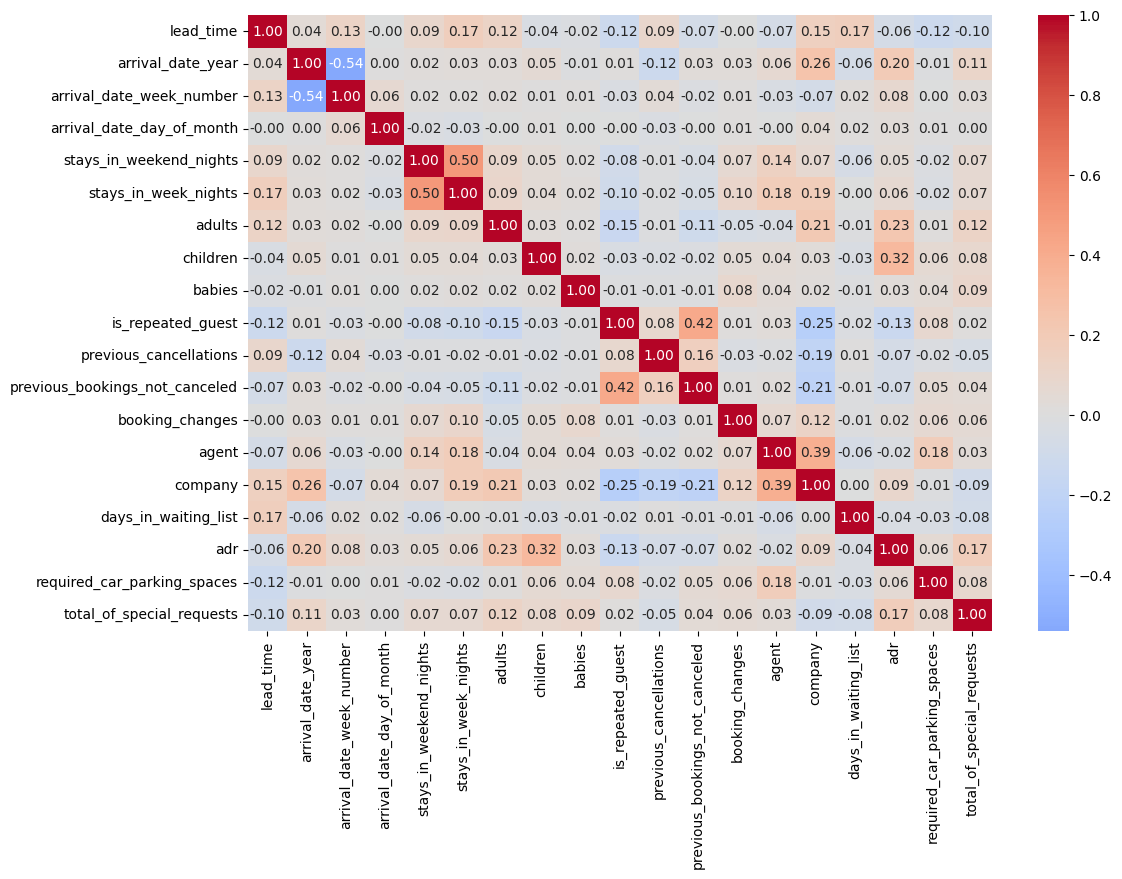

In [148]:
# Heatmap de correlación
corr = X_train.select_dtypes(include='number').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()



Podemos ver que las variables `is_repeated_guest` y `previous_bookings_not_canceled` son parcialmente redundantes. Por un lado es lógico ya que si un cliente ha tenido reservas previas no canceladas, es más probable que sea un cliente repetidor.  

Por otro lado las variables `stays_in_week_nights` y `stays_in_weekend_nights` también están bastante correladas, ya que quien se queda muchas noches entresemana suele quedarse también los fines de semana. De hecho podrían combinarse en una sola `total_nights`  

También se observa una correlación, pero ligera entre adults y adr, así como entre children y adr. Esto es coherente con el comportamiento habitual del sector hotelero: las reservas con adultos suelen asociarse a tarifas más elevadas, mientras que las reservas con niños tienden a corresponder a habitaciones familiares o paquetes con precios medios más bajos. La variable babies, en cambio, no muestra correlación relevante debido a su baja variabilidad. No es una multicolinealidad fuerte que requiera eliminar ninguna de las variables

In [149]:
for col in num_cols:
# Outliers por IQR
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR))
    print(f"Outliers:{col }  {outliers.sum()}")
    


Outliers:lead_time  2386
Outliers:arrival_date_year  0
Outliers:arrival_date_week_number  0
Outliers:arrival_date_day_of_month  0
Outliers:stays_in_weekend_nights  211
Outliers:stays_in_week_nights  2696
Outliers:adults  23857
Outliers:children  6844
Outliers:babies  710
Outliers:is_repeated_guest  3014
Outliers:previous_cancellations  5171
Outliers:previous_bookings_not_canceled  2887
Outliers:booking_changes  14423
Outliers:agent  0
Outliers:days_in_waiting_list  2966
Outliers:adr  2997
Outliers:required_car_parking_spaces  5906
Outliers:total_of_special_requests  2295


El análisis de outliers mediante IQR muestra un número elevado de valores marcados como extremos en varias variables.  

Sin embargo, este resultado debe interpretarse con cautela. En variables continuas como `lead_time` y `adr`, los outliers reflejan comportamientos reales del negocio y no representan un problema. En cambio, en variables discretas o binarias (como `children`, `babies`, `adults`, `is_repeated_guest`, `required_car_parking_spaces` o `total_of_special_requests`), el método IQR no es adecuado, ya que genera rangos muy estrechos y clasifica como outliers valores perfectamente normales.   

Por tanto, la presencia de muchos outliers en estas variables no indica un problema real en los datos. En esta fase se documentan, pero no se eliminan ni transforman, ya que su tratamiento dependerá del modelo seleccionado.

# 4. FEATURE ENGINEERING

## 4.1. NUMERIC FEATURES  
Se crearán variables que resuman la información redundante, cputren relaciones no lineales, aporten contexto y mejoren la capacidad predictiva el modelo

Se crea una variable **`total_nights`** sustituye dos variables muy correladas `stays_in_week_nights`y `stays_in_weekend_nights`

In [150]:
X_train['total_nights'] = (
    X_train['stays_in_week_nights'] + 
    X_train['stays_in_weekend_nights']
)

X_test['total_nights'] = (
    X_test['stays_in_week_nights'] + 
    X_test['stays_in_weekend_nights']
)

Creamos una variable **`is_family`** puede ser útil en modelos basados en árboles. Normalmente las familias (reservas en las que hay niños y/o bebés) son más estables.

In [151]:
X_train['is_family'] = (
    (X_train['children'] > 0) | (X_train['babies'] > 0)
).astype(int)

X_test['is_family'] = (
    (X_test['children'] > 0) | (X_test['babies'] > 0)
).astype(int)



Creamos una variable **`total_guests`** captura el tamaño del grupo. Ya que el tamaño del grupo influye en las cancelaciones y es más informativa que cada variable por separado

In [152]:
# Crear total_guests
X_train['total_guests'] = (
    X_train['adults'] +
    X_train['children'] +
    X_train['babies']
)

X_test['total_guests'] = (
    X_test['adults'] +
    X_test['children'] +
    X_test['babies']
)

Creamos una variable **`adr_per_person`** nos puede indicar el precio por persona para tener una visión más realista del coste

In [153]:
X_train['adr_per_person'] = X_train['adr'] / X_train['total_guests'].replace(0,1)
X_test['adr_per_person'] = X_test['adr'] / X_test['total_guests'].replace(0,1)


Visualización de las nuevas variables numéricas en X_train creadas también en X_test

In [154]:
X_train[['total_nights', 'is_family', 'adr', 'total_guests', 'adr_per_person']].head()

,total_nights,is_family,adr,total_guests,adr_per_person
105447,2,0,98.0,1.0,98.0
85242,3,0,100.0,2.0,50.0
65604,3,0,95.0,2.0,47.5
17345,14,0,54.0,2.0,27.0
117786,1,0,80.0,1.0,80.0


## 4.2 DATE FEATURES

Reconstruimos fecha

In [155]:
# Reconstruir fecha completa
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

for df in [X_train, X_test]:
    df['month_num'] = df['arrival_date_month'].str.strip().map(month_map)

    df['arrival_date'] = pd.to_datetime(
        df['arrival_date_year'].astype(int).astype(str) + '-' +
        df['month_num'].astype(int).astype(str) + '-' +
        df['arrival_date_day_of_month'].astype(int).astype(str),
        format='%Y-%m-%d'
    )

Añadimos una columna de 'temporada' que mapee la columna arrival_date_month

In [156]:
season_map = {
    'December':'Winter','January':'Winter','February':'Winter',
    'March':'Spring','April':'Spring','May':'Spring',
    'June':'Summer','July':'Summer','August':'Summer',
    'September':'Autumn','October':'Autumn','November':'Autumn'
}

X_train['season'] = X_train['arrival_date_month'].map(season_map)
X_test['season'] = X_test['arrival_date_month'].map(season_map)

In [157]:
# Día de la semana. El día de la semana sí puede tener relación con el comportamiento del cliente. 
# Mientras que el año, la semana del año el día del mes o la fecha del mes aportan poco o nada, es cierto que el día de la semana 
# sí puede reflejar cierto patrón en las cancelaciones
X_train['arrival_day_of_week'] = X_train['arrival_date'].dt.dayofweek
X_test['arrival_day_of_week'] = X_test['arrival_date'].dt.dayofweek



Aunque es posible reconstruir la fecha completa y obtener el día de la semana, las variables derivadas como `arrival_day_of_week` o `is_weekend_arrival` no aportan información relevante en este dataset. La cancelación no muestra patrones semanales, por lo que estas variables pueden omitirse sin pérdida de rendimiento. En cambio, sí se mantienen variables temporales más informativas como `season` y `lead_time` que capturan estacionalidad y comportamiento de planificación del cliente.

Visualización de las nuevas variables de fecha creadas en X_train creadas también en X_test

In [158]:
X_train[['arrival_date', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'season', 'arrival_day_of_week']].head()

,arrival_date,arrival_date_year,arrival_date_month,arrival_date_day_of_month,season,arrival_day_of_week
105447,2017-02-07,2017,February,7,Winter,1
85242,2016-03-09,2016,March,9,Spring,2
65604,2017-04-06,2017,April,6,Spring,3
17345,2015-09-23,2015,September,23,Autumn,2
117786,2017-08-09,2017,August,9,Summer,2


In [159]:
X_train.head(20)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reservation_status,reservation_status_date,total_nights,is_family,total_guests,adr_per_person,month_num,arrival_date,season,arrival_day_of_week
105447,City Hotel,20,2017,February,6,7,0,2,1,0.0,...,Check-Out,2017-02-09,2,0,1.0,98.000,2,2017-02-07,Winter,1
85242,City Hotel,8,2016,March,11,9,0,3,2,0.0,...,Check-Out,2016-03-12,3,0,2.0,50.000,3,2016-03-09,Spring,2
65604,City Hotel,93,2017,April,14,6,0,3,2,0.0,...,Canceled,2017-01-03,3,0,2.0,47.500,4,2017-04-06,Spring,3
17345,Resort Hotel,90,2015,September,39,23,4,10,2,0.0,...,Check-Out,2015-10-07,14,0,2.0,27.000,9,2015-09-23,Autumn,2
117786,City Hotel,8,2017,August,32,9,0,1,1,0.0,...,Check-Out,2017-08-10,1,0,1.0,80.000,8,2017-08-09,Summer,2
46470,City Hotel,150,2016,January,1,2,2,1,2,0.0,...,Canceled,2015-11-04,3,0,2.0,50.500,1,2016-01-02,Winter,5
71278,City Hotel,158,2017,July,26,1,1,1,2,0.0,...,Canceled,2017-02-14,2,0,2.0,44.550,7,2017-07-01,Summer,5
102626,City Hotel,14,2016,December,49,2,0,1,2,2.0,...,Check-Out,2016-12-03,1,1,4.0,43.500,12,2016-12-02,Winter,4
108817,City Hotel,15,2017,March,13,31,0,2,1,0.0,...,Check-Out,2017-04-02,2,0,1.0,111.000,3,2017-03-31,Spring,4
100158,City Hotel,77,2016,October,43,20,1,3,2,0.0,...,Check-Out,2016-10-24,4,0,2.0,45.475,10,2016-10-20,Autumn,3


## 4.3 BINING

Columnas a discretizar: `lead_time`,`adr` y `total_nights`. Se usarán cuartiles por es un estándar en modelos lineales, árboles y datasets con un fuerte sesgo como es nuestro caso.
Dado el importante sesgo de estas tres variables (`lead_time` tiene una cola muy larga, `adr` muchos outliers y `total_nights` una distribución muy asimétrica) no conviene usar intervalos iguales ya que casi todos los datos caerían en el primer bin.

Discretización de `lead_time`

In [160]:
# qcut divide la variable en cuantiles con q = 4: Q1 25%, Q2 50% Q3 75% Y Q4 100%. Cuatro grupos con el mismo número de observaciones pero con rangos distintos
# especialmente últil cuando la variable está muy sesgada
bins_lead = pd.qcut(X_train['lead_time'], q=4, retbins=True)[1]
bins_lead


array([  0.,  18.,  69., 160., 737.])

In [161]:
# aplicamos esos bins a train y test pero con pd.cut. Se calculan los bin en tran y se aplican en test
X_train['lead_time_bin'] = pd.cut(X_train['lead_time'], bins=bins_lead, labels=['very_short','short','medium','long'], include_lowest=True)
X_test['lead_time_bin'] = pd.cut(X_test['lead_time'], bins=bins_lead, labels=['very_short','short','medium','long'], include_lowest=True)

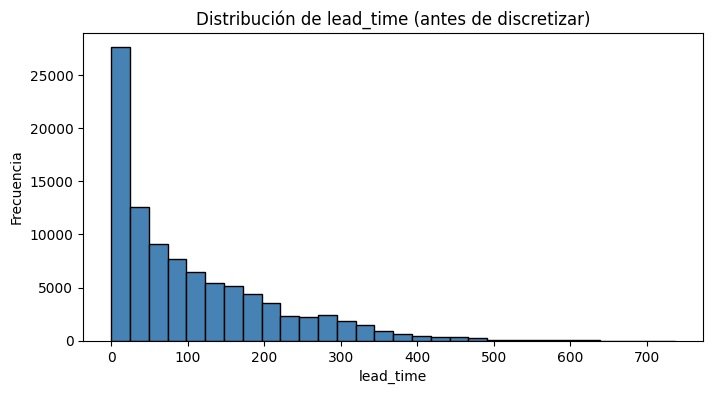

In [162]:
plt.figure(figsize=(8,4))
plt.hist(X_train['lead_time'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribución de lead_time (antes de discretizar)')
plt.xlabel('lead_time')
plt.ylabel('Frecuencia')
plt.show()


C:\Users\m_fon\AppData\Local\Temp\ipykernel_23500\3329075177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X_train['lead_time_bin'], palette='viridis')


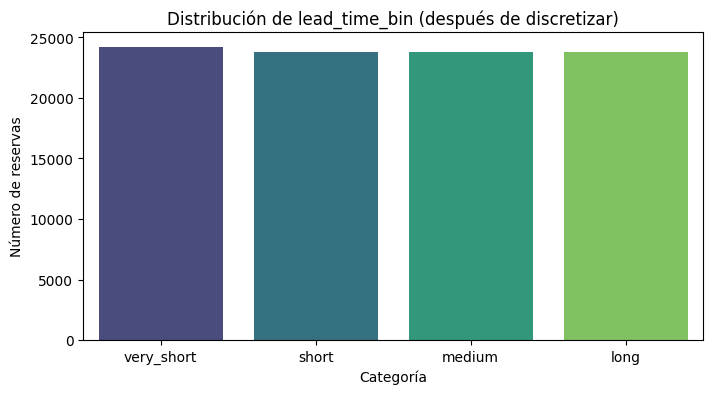

In [163]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['lead_time_bin'], palette='viridis')
plt.title('Distribución de lead_time_bin (después de discretizar)')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

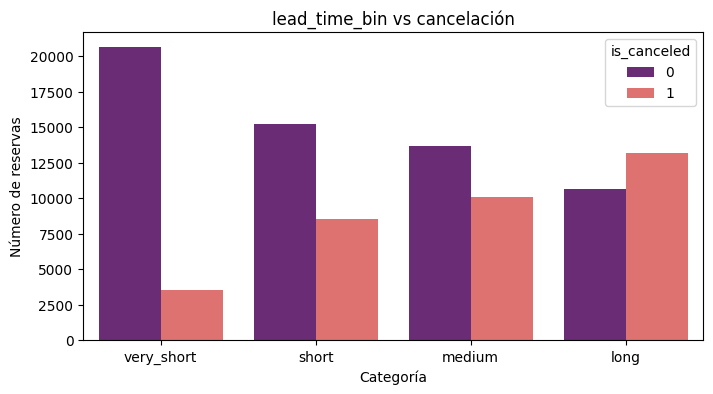

In [164]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['lead_time_bin'], hue=y_train, palette='magma')
plt.title('lead_time_bin vs cancelación')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

Discretización de `adr`

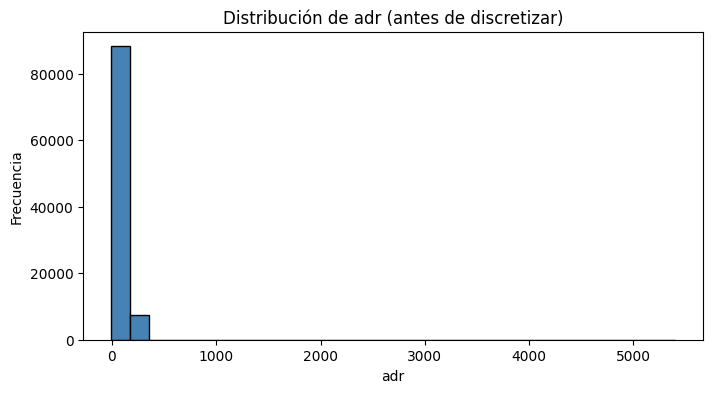

In [165]:
plt.figure(figsize=(8,4))
plt.hist(X_train['adr'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribución de adr (antes de discretizar)')
plt.xlabel('adr')
plt.ylabel('Frecuencia')
plt.show()


In [166]:
bins_adr = pd.qcut(X_train['adr'], q=4, retbins=True)[1]

X_train['adr_bin'] = pd.cut(X_train['adr'], bins=bins_adr, labels=['low','medium_low','medium_high','high'], include_lowest=True)
X_test['adr_bin'] = pd.cut(X_test['adr'], bins=bins_adr, labels=['low','medium_low','medium_high','high'], include_lowest=True)
bins_adr

array([  -6.38,   69.29,   94.5 ,  126.  , 5400.  ])

C:\Users\m_fon\AppData\Local\Temp\ipykernel_23500\758515974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X_train['adr_bin'], palette='viridis')


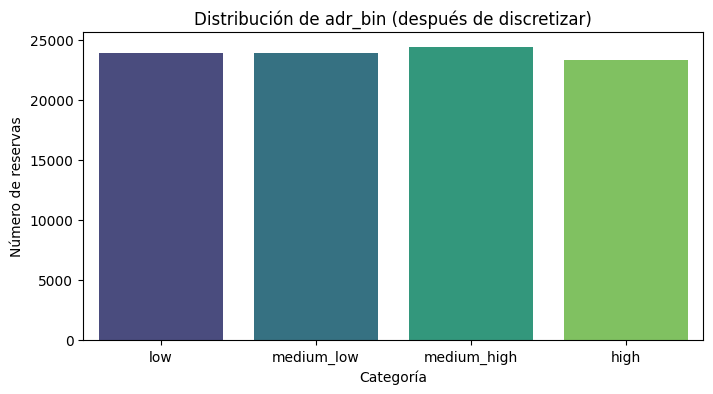

In [167]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['adr_bin'], palette='viridis')
plt.title('Distribución de adr_bin (después de discretizar)')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

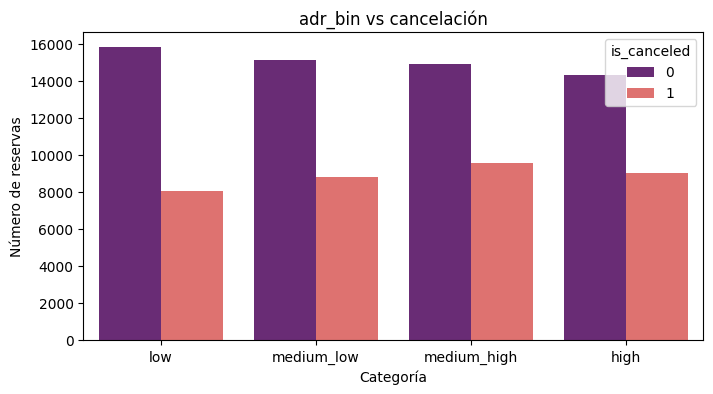

In [168]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['adr_bin'], hue=y_train, palette='magma')
plt.title('adr_bin vs cancelación')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

Discretización de `total_nights`

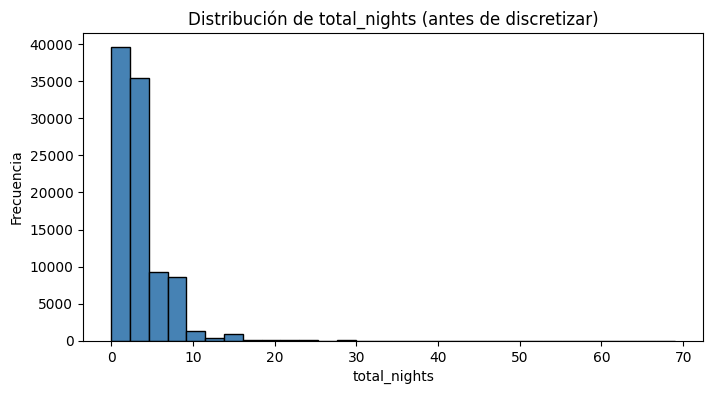

In [169]:
plt.figure(figsize=(8,4))
plt.hist(X_train['total_nights'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribución de total_nights (antes de discretizar)')
plt.xlabel('total_nights')
plt.ylabel('Frecuencia')
plt.show()

In [170]:
# Discretización de total_nights
bins_nights = pd.qcut(X_train['total_nights'], q=4, retbins=True)[1]

X_train['total_nights_bin'] = pd.cut(X_train['total_nights'], bins=bins_nights, labels=['short','medium','long','extended'], include_lowest=True)
X_test['total_nights_bin'] = pd.cut(X_test['total_nights'], bins=bins_nights, labels=['short','medium','long','extended'], include_lowest=True)
bins_nights

array([ 0.,  2.,  3.,  4., 69.])

C:\Users\m_fon\AppData\Local\Temp\ipykernel_23500\1411764438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=X_train['total_nights_bin'], palette='viridis')


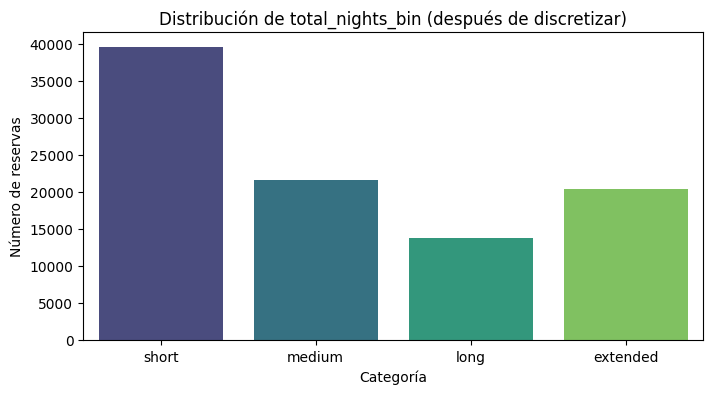

In [171]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['total_nights_bin'], palette='viridis')
plt.title('Distribución de total_nights_bin (después de discretizar)')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

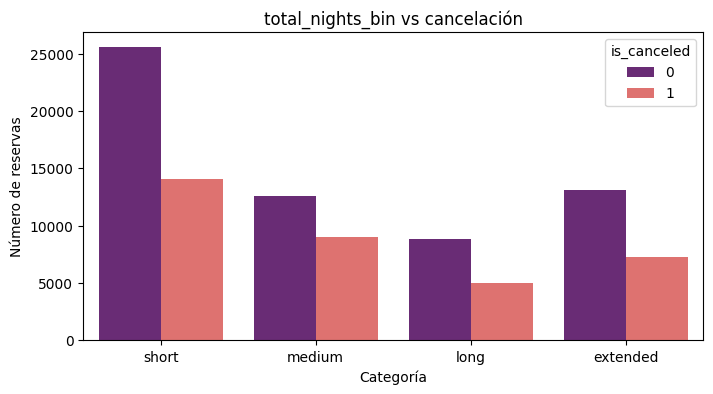

In [172]:
plt.figure(figsize=(8,4))
sns.countplot(x=X_train['total_nights_bin'], hue=y_train, palette='magma')
plt.title('total_nights_bin vs cancelación')
plt.xlabel('Categoría')
plt.ylabel('Número de reservas')
plt.show()

Se discretizaron las variables `lead_time`, `adr` y `total_nights`, ya que presentan distribuciones muy sesgadas y valores extremos. La discretización mediante cuartiles permite capturar relaciones no lineales, reducir el impacto de outliers y mejorar la interpretabilidad del modelo. Las discretizaciones se aplicaron utilizando los mismos cortes en train y test para evitar data leakage. El resto de variables numéricas no se discretizaron, ya que son discretas por naturaleza o no se benefician de este tipo de transformación.

In [173]:
X_train


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,is_family,total_guests,adr_per_person,month_num,arrival_date,season,arrival_day_of_week,lead_time_bin,adr_bin,total_nights_bin
105447,City Hotel,20,2017,February,6,7,0,2,1,0.0,...,0,1.0,98.000,2,2017-02-07,Winter,1,short,medium_high,short
85242,City Hotel,8,2016,March,11,9,0,3,2,0.0,...,0,2.0,50.000,3,2016-03-09,Spring,2,very_short,medium_high,medium
65604,City Hotel,93,2017,April,14,6,0,3,2,0.0,...,0,2.0,47.500,4,2017-04-06,Spring,3,medium,medium_high,medium
17345,Resort Hotel,90,2015,September,39,23,4,10,2,0.0,...,0,2.0,27.000,9,2015-09-23,Autumn,2,medium,low,extended
117786,City Hotel,8,2017,August,32,9,0,1,1,0.0,...,0,1.0,80.000,8,2017-08-09,Summer,2,very_short,medium_low,short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104906,City Hotel,22,2017,January,3,19,2,4,1,0.0,...,0,1.0,58.240,1,2017-01-19,Winter,3,short,low,extended
50818,City Hotel,18,2016,May,20,9,1,2,1,0.0,...,0,1.0,136.000,5,2016-05-09,Spring,0,very_short,high,medium
36939,Resort Hotel,135,2017,May,22,30,0,3,2,0.0,...,0,2.0,47.485,5,2017-05-30,Spring,1,medium,medium_high,medium
14587,Resort Hotel,172,2017,June,24,14,2,5,2,0.0,...,0,2.0,56.700,6,2017-06-14,Summer,2,long,medium_high,extended


# 5. PREPROCESADO

#### "Re-check" inicial de tipos:

In [174]:
X_train.dtypes

hotel                                     object
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type                        object
booking_changes     

#### Fuerce de tipos correctos de columnas

In [175]:
# agent y company son IDs, no cantidades: forzamos a categórico
# (astype no calcula nada a partir de los datos, así que no hay fuga por aplicarlo igual en los dos)
for df_ in [X_train, X_test]:
    df_['agent'] = df_['agent'].astype('object')
    df_['company'] = df_['company'].astype('object')  # si no la has eliminado ya

# children, babies, adults: enteros, sin decimales raros
# esto es solo un chequeo (print), no transforma nada -> conviene mirar train Y test
for nombre, df_ in [('train', X_train), ('test', X_test)]:
    for col in ['children', 'babies', 'adults']:
        if df_[col].dtype == float:
            ok = df_[col].apply(float.is_integer).all()
            print(f"[{nombre}] {col}: {df_[col].dtype} — todos enteros: {ok}")
        else:
            print(f"[{nombre}] {col}: {df_[col].dtype} — ok")

# Fecha real a partir de year/month/day — solo para verificar que no da error
# también un chequeo, se hace en los dos por la misma razón
for nombre, df_ in [('train', X_train), ('test', X_test)]:
    fecha_check = pd.to_datetime(
        df_['arrival_date_year'].astype(str) + '-' +
        df_['arrival_date_month'] + '-' +
        df_['arrival_date_day_of_month'].astype(str),
        format='%Y-%B-%d', errors='coerce'
    )
    print(f"[{nombre}] Fechas no parseadas: {fecha_check.isna().sum()}")

[train] children: float64 — todos enteros: False
[train] babies: int64 — ok
[train] adults: int64 — ok
[test] children: float64 — todos enteros: True
[test] babies: int64 — ok
[test] adults: int64 — ok
[train] Fechas no parseadas: 95512
[test] Fechas no parseadas: 23878


#### Feature selection - drop

In [176]:
# Columnas específicas
    ## Se eliminan 'company' por alto contenido de nulos (94.306%) y 'reservation_status', 'reservation_status_date' 
    # por riesgo de leakage como se menciona en apartados del EDA

cols_descartables = ['company', 'reservation_status', 'reservation_status_date']   
X_train.drop(columns=cols_descartables, inplace=True)
X_test.drop(columns=cols_descartables,  inplace=True)

print(f"Columnas restantes: {X_train.shape[1]}")

Columnas restantes: 39


In [177]:
# Columnas de fecha ya no necesarias tras extraer 'season'
# (arrival_date_month se dropea aparte en la celda de encoding cíclico, no hace falta repetirla aquí)
cols_fecha_descartables = [
    'arrival_date',
    'arrival_date_year',
    'arrival_date_day_of_month',
    'arrival_date_week_number',
    'month_num',
    'arrival_day_of_week',
]

X_train = X_train.drop(columns=cols_fecha_descartables)
X_test = X_test.drop(columns=cols_fecha_descartables)

print(f"Columnas restantes tras eliminar fecha: {X_train.shape[1]}")

Columnas restantes tras eliminar fecha: 33


#### Los duplicados

In [178]:
##dup_mask = X_train.duplicated()
##print(f"Duplicados encontrados: {dup_mask.sum()}")
##X_train = X_train[~dup_mask]
##y_train = y_train[~dup_mask]

In [179]:
# Comprobación si los duplicados existen antes del split (referencia: dataset original)
df_raw = pd.read_csv('src/data_sample/hotel_bookings.csv')
print(f"Duplicados en el CSV original: {df_raw.duplicated().sum()} ({df_raw.duplicated().mean()*100:.1f}%)")

# Cuántos hay en tu X_train actual (sin eliminar nada)
dup_mask = X_train.duplicated(keep=False)  # keep=False marca TODAS las copias, no solo la 2ª+
print(f"Filas implicadas en duplicados en X_train: {dup_mask.sum()} ({dup_mask.mean()*100:.1f}%)")

# Inspecciona un grupo de duplicados
grupo_ejemplo = X_train[dup_mask].sort_values(list(X_train.columns)).head(10)
grupo_ejemplo

# ¿Se concentran en pocas combinaciones repetidas muchas veces, o es ruido disperso?
X_train[dup_mask].value_counts().head(10)

Duplicados en el CSV original: 31994 (26.8%)
Filas implicadas en duplicados en X_train: 31238 (32.7%)


hotel       lead_time  arrival_date_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies  meal  country  market_segment  distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  reserved_room_type  assigned_room_type  booking_changes  deposit_type  agent  days_in_waiting_list  customer_type    adr    required_car_parking_spaces  total_of_special_requests  total_nights  is_family  total_guests  adr_per_person  season  lead_time_bin  adr_bin      total_nights_bin
City Hotel  68         February            0                        2                     2       0.0       0       BB    PRT      Groups          TA/TO                 0                  1                       0                               A                   A                   0                Non Refund    37.0   0                     Transient        75.0   0                            0                          2             0          2.0           37.5 

### Duplicados — decisión: no se eliminan

Se detectan 31.994 filas duplicadas exactas en el CSV original (26,8%), y
30.960 filas de X_train están implicadas en algún duplicado (32,4% de train).
Esto es consistente con la anonimización del dataset (Antonio, Almeida &
Nunes, 2019), que elimina cualquier identificador de reserva o de cliente:
dos huéspedes distintos que reserven en las mismas condiciones (mismo hotel,
mes, tipo de habitación, canal, precio...) quedan indistinguibles en los datos.

Como no hay forma de comprobar si cada duplicado es un error de captura o una
coincidencia legítima entre dos reservas reales, y dado que casi un tercio de
train está implicado, se decide **no eliminarlos** por prudencia: eliminar sin
certeza a esta escala podría estar descartando observaciones reales en vez de
ruido. Se deja documentado el hallazgo para que quede trazable en la
evaluación, aunque no se actúe sobre él.

#### Outliers

In [180]:
# Umbral calculado SOLO sobre train (percentil 99)
p99 = X_train['adr'].quantile(0.99)
print(f"Percentil 99 de adr: {p99:.2f}")

X_train['adr'] = X_train['adr'].clip(upper=p99)
X_test['adr'] = X_test['adr'].clip(upper=p99)  # mismo umbral, calculado en train

print(f"Máximo adr tras el capeo: {X_train['adr'].max():.2f}")

Percentil 99 de adr: 251.13
Máximo adr tras el capeo: 251.13


# Imputación

Regla de oro: Calculamos moda/media/mediana solo sobre X_train y aplica esos mismos valores a X_test. 
Con **SimpleImputer** de sklearn -- *fit* en train, *transform* en ambos.

In [181]:
from sklearn.impute import SimpleImputer

# children: nulo -> 0 (sin hijos es el caso más común)
X_train['children'] = X_train['children'].fillna(0)
X_test['children'] = X_test['children'].fillna(0)

# country: nulo -> moda calculada SOLO sobre train
imp_country = SimpleImputer(strategy='most_frequent')
X_train['country'] = imp_country.fit_transform(X_train[['country']]).ravel()
X_test['country'] = imp_country.transform(X_test[['country']]).ravel()

# agent: nulo -> 0 ("sin agencia", no es un missing real)
X_train['agent'] = X_train['agent'].fillna(0)
X_test['agent'] = X_test['agent'].fillna(0)

# Verificación final
print((X_train.isnull().mean() * 100).round(3).sort_values(ascending=False).head())

adr_per_person        0.004
total_guests          0.004
hotel                 0.000
lead_time             0.000
arrival_date_month    0.000
dtype: float64


C:\Users\m_fon\AppData\Local\Temp\ipykernel_23500\2636188503.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['agent'] = X_train['agent'].fillna(0)
C:\Users\m_fon\AppData\Local\Temp\ipykernel_23500\2636188503.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['agent'] = X_test['agent'].fillna(0)


#### Categorical Encoding

In [182]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- One-Hot: hotel, meal, market_segment, distribution_channel, customer_type, deposit_type,
#     reserved_room_type, assigned_room_type ---
cols_ohe = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type',
            'deposit_type', 'reserved_room_type', 'assigned_room_type', 'season']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[cols_ohe])

train_ohe = pd.DataFrame(ohe.transform(X_train[cols_ohe]), columns=ohe.get_feature_names_out(cols_ohe), index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[cols_ohe]), columns=ohe.get_feature_names_out(cols_ohe), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cols_ohe), train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns=cols_ohe), test_ohe], axis=1)

# --- country: Top-20 + "Other" antes del OHE ---
top20 = X_train['country'].value_counts().nlargest(20).index
X_train['country'] = X_train['country'].where(X_train['country'].isin(top20), 'Other')
X_test['country'] = X_test['country'].where(X_test['country'].isin(top20), 'Other')
X_train = pd.get_dummies(X_train, columns=['country'], prefix='country')
X_test = pd.get_dummies(X_test, columns=['country'], prefix='country')
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# --- agent, company: binary "tiene_agente" ---
X_train['tiene_agente'] = (X_train['agent'] != 0).astype(int)
X_test['tiene_agente'] = (X_test['agent'] != 0).astype(int)
X_train = X_train.drop(columns=['agent'])
X_test = X_test.drop(columns=['agent'])

# --- arrival_date_month / season: encoding cíclico ---
meses = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
         'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
for df_ in [X_train, X_test]:
    mes_num = df_['arrival_date_month'].map(meses)
    df_['mes_sin'] = np.sin(2 * np.pi * mes_num / 12)
    df_['mes_cos'] = np.cos(2 * np.pi * mes_num / 12)
X_train = X_train.drop(columns=['arrival_date_month'])
X_test = X_test.drop(columns=['arrival_date_month'])

# --- lead_time_bin, adr_bin, total_nights_bin: Ordinal Encoding ---
ordenes = {
    'lead_time_bin': ['very_short', 'short', 'medium', 'long'],
    'adr_bin': ['low', 'medium_low', 'medium_high', 'high'],
    'total_nights_bin': ['short', 'medium', 'long', 'extended'],
}
for col, orden in ordenes.items():
    mapping = {v: i for i, v in enumerate(orden)}
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

#### Feature Scaler

In [183]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Columnas con outliers marcados -> RobustScaler
cols_robust = ['adr', 'lead_time']
robust_scaler = RobustScaler()
X_train[cols_robust] = robust_scaler.fit_transform(X_train[cols_robust])
X_test[cols_robust] = robust_scaler.transform(X_test[cols_robust])

# Resto de numéricas -> StandardScaler
cols_num = X_train.select_dtypes(include='number').columns.difference(cols_robust)
scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Solo aplica este bloque si vas a probar Regresión Logística, SVM o KNN.
# Para Random Forest / XGBoost / LightGBM puedes saltarte el escalado.

#### Feature Selection - Random Forest Classifier

In [184]:
# Los nulos de adr_per_person y total_guests vienen de children (ya imputado arriba).
# Recalculamos las derivadas para que queden consistentes, en vez de imputarlas sueltas.

for df_ in [X_train, X_test]:
    df_['total_guests'] = df_['adults'] + df_['children'] + df_['babies']
    df_['adr_per_person'] = df_['adr'] / df_['total_guests'].replace(0, 1)  # protección para 0 huéspedes

# Verificación
print((X_train.isnull().mean() * 100).round(3).sort_values(ascending=False).head())

lead_time                  0.0
stays_in_weekend_nights    0.0
stays_in_week_nights       0.0
adults                     0.0
children                   0.0
dtype: float64


In [185]:
print(X_train.dtypes.value_counts())
print(X_train.select_dtypes(include='object').columns.tolist())

float64     74
bool        21
category     3
Name: count, dtype: int64
[]


In [186]:
from sklearn.ensemble import RandomForestClassifier

# Importancia por Random Forest
rf_quick = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_quick.fit(X_train, y_train)

importances = pd.Series(rf_quick.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(20))

# Features con importancia casi nula -> candidatas a descartar
cols_poco_utiles = importances[importances < 0.001].index.tolist()
print(f"Features con importancia < 0.001: {len(cols_poco_utiles)}")

# --- 2. Multicolinealidad entre dummies (OHE / country) ---
# Para variables binarias 0/1, Pearson entre dummies funciona como proxy razonable
# de asociación (no hace falta Cramér's V aquí porque ya son numéricas 0/1).
dummy_prefixes = ('country_', 'hotel_', 'meal_', 'market_segment_',
                   'distribution_channel_', 'customer_type_', 'deposit_type_',
                   'reserved_room_type_', 'assigned_room_type_')

dummy_cols = [c for c in X_train.columns if c.startswith(dummy_prefixes)]

corr_dummies = X_train[dummy_cols].corr().abs()

# Nos quedamos con pares (no la diagonal) con correlación alta
umbral_corr = 0.8
pares_altos = (
    corr_dummies.where(np.triu(np.ones(corr_dummies.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
pares_altos = pares_altos[pares_altos > umbral_corr]
print(f"\nPares de dummies con |corr| > {umbral_corr}:")
print(pares_altos)

# --- 3. Combinar ambos criterios y descartar ---
# De cada par muy correlado, nos quedamos con la primera columna del par (criterio simple)
cols_redundantes = sorted(set(idx[1] for idx in pares_altos.index))

cols_a_eliminar = sorted(set(cols_poco_utiles) | set(cols_redundantes))
print(f"\nTotal columnas a eliminar (poco útiles + redundantes): {len(cols_a_eliminar)}")

X_train = X_train.drop(columns=cols_a_eliminar)
X_test = X_test.drop(columns=cols_a_eliminar)

print(f"Columnas finales: {X_train.shape[1]}")

lead_time                      0.097836
deposit_type_Non Refund        0.074067
country_PRT                    0.064261
deposit_type_No Deposit        0.061849
adr                            0.059209
adr_per_person                 0.056604
total_of_special_requests      0.052910
lead_time_bin                  0.036229
total_nights                   0.027259
stays_in_week_nights           0.026813
previous_cancellations         0.024718
mes_sin                        0.023555
mes_cos                        0.022953
market_segment_Online TA       0.022440
stays_in_weekend_nights        0.019227
required_car_parking_spaces    0.018452
booking_changes                0.018310
customer_type_Transient        0.015853
total_nights_bin               0.015631
adr_bin                        0.014964
dtype: float64
Features con importancia < 0.001: 22

Pares de dummies con |corr| > 0.8:
hotel_City Hotel         hotel_Resort Hotel               1.000000
reserved_room_type_P     assigned_room_type_P

## Encapsulamos todo en un Pipeline

In [187]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler


class ColumnDropper(BaseEstimator, TransformerMixin):
    """Elimina columnas con leakage / nulos altos."""
    def __init__(self, cols_a_eliminar):
        self.cols_a_eliminar = cols_a_eliminar

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        presentes = [c for c in self.cols_a_eliminar if c in X.columns]
        return X.drop(columns=presentes)


class NumericFeatureEngineer(BaseEstimator, TransformerMixin):
    """total_nights, is_family, total_guests, adr_per_person."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['total_nights'] = X['stays_in_week_nights'] + X['stays_in_weekend_nights']
        X['is_family'] = ((X['children'] > 0) | (X['babies'] > 0)).astype(int)
        X['total_guests'] = X['adults'] + X['children'] + X['babies']
        X['adr_per_person'] = X['adr'] / X['total_guests'].replace(0, 1)
        return X


class DateFeatureEngineer(BaseEstimator, TransformerMixin):
    """season, mes_sin, mes_cos. Elimina las columnas de fecha crudas ya no necesarias."""
    MESES = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
    SEASON_MAP = {
        'December':'Winter','January':'Winter','February':'Winter',
        'March':'Spring','April':'Spring','May':'Spring',
        'June':'Summer','July':'Summer','August':'Summer',
        'September':'Autumn','October':'Autumn','November':'Autumn'
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        mes_num = X['arrival_date_month'].str.strip().map(self.MESES)
        X['season'] = X['arrival_date_month'].map(self.SEASON_MAP)
        X['mes_sin'] = np.sin(2 * np.pi * mes_num / 12)
        X['mes_cos'] = np.cos(2 * np.pi * mes_num / 12)

        descartables = ['arrival_date_year', 'arrival_date_month',
                         'arrival_date_day_of_month', 'arrival_date_week_number']
        return X.drop(columns=[c for c in descartables if c in X.columns])


class QuantileBinner(BaseEstimator, TransformerMixin):
    """Discretiza lead_time, adr, total_nights en cuartiles (bins aprendidos en fit) + ordinal encoding."""
    LABELS = {
        'lead_time': ['very_short', 'short', 'medium', 'long'],
        'adr': ['low', 'medium_low', 'medium_high', 'high'],
        'total_nights': ['short', 'medium', 'long', 'extended'],
    }

    def __init__(self, cols=('lead_time', 'adr', 'total_nights')):
        self.cols = list(cols)

    def fit(self, X, y=None):
        self.bin_edges_ = {
            col: pd.qcut(X[col], q=4, retbins=True, duplicates='drop')[1]
            for col in self.cols
        }
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            labels = self.LABELS[col]
            cats = pd.cut(X[col], bins=self.bin_edges_[col], labels=labels, include_lowest=True)
            mapping = {v: i for i, v in enumerate(labels)}
            X[f'{col}_bin'] = cats.map(mapping).astype("float32")
        return X


class ManualImputer(BaseEstimator, TransformerMixin):
    """children/agent -> 0; country -> moda de train. Recalcula derivadas tras imputar."""
    def fit(self, X, y=None):
        self.imp_country_ = SimpleImputer(strategy='most_frequent')
        self.imp_country_.fit(X[['country']])
        return self

    def transform(self, X):
        X = X.copy()
        X['children'] = X['children'].fillna(0)
        X['agent'] = X['agent'].fillna(0)
        X['country'] = self.imp_country_.transform(X[['country']]).ravel()
        X['total_guests'] = X['adults'] + X['children'] + X['babies']
        X['adr_per_person'] = X['adr'] / X['total_guests'].replace(0, 1)
        return X


class OutlierCapper(BaseEstimator, TransformerMixin):
    """Capea adr al percentil 99 de train."""
    def fit(self, X, y=None):
        self.p99_ = X['adr'].quantile(0.99)
        return self

    def transform(self, X):
        X = X.copy()
        X['adr'] = X['adr'].clip(upper=self.p99_)
        return X


class CountryGrouper(BaseEstimator, TransformerMixin):
    """country -> Top-20 de train + 'Other'."""
    def fit(self, X, y=None):
        self.top20_ = X['country'].value_counts().nlargest(20).index
        return self

    def transform(self, X):
        X = X.copy()
        X['country'] = X['country'].where(X['country'].isin(self.top20_), 'Other')
        return X


class AgentFlagger(BaseEstimator, TransformerMixin):
    """agent -> tiene_agente (binaria), elimina agent."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['tiene_agente'] = (X['agent'] != 0).astype(int)
        return X.drop(columns=['agent'])


class OneHotWrapper(BaseEstimator, TransformerMixin):
    """One-Hot para todas las categóricas (incluye country ya agrupada y season)."""
    def __init__(self, cols):
        self.cols = list(cols)

    def fit(self, X, y=None):
        self.ohe_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.ohe_.fit(X[self.cols])
        return self

    def transform(self, X):
        X = X.copy()
        ohe_arr = self.ohe_.transform(X[self.cols])
        ohe_df = pd.DataFrame(
            ohe_arr,
            columns=self.ohe_.get_feature_names_out(self.cols),
            index=X.index
        ).astype(np.float32)

        X = pd.concat(
            [X.drop(columns=self.cols), ohe_df],
            axis=1
        )
        for c in X.columns:
            if X[c].dtype == "object":
                X[c] = pd.to_numeric(X[c], errors="ignore")

            return X

class Scaler(BaseEstimator, TransformerMixin):
    """RobustScaler para adr/lead_time, StandardScaler para el resto de numéricas."""
    def __init__(self, cols_robust=('adr', 'lead_time')):
        self.cols_robust = list(cols_robust)

    def fit(self, X, y=None):
        self.robust_scaler_ = RobustScaler().fit(X[self.cols_robust])
        self.cols_num_ = X.select_dtypes(include='number').columns.difference(self.cols_robust)
        self.scaler_ = StandardScaler().fit(X[self.cols_num_])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols_robust] = self.robust_scaler_.transform(X[self.cols_robust])
        X[self.cols_num_] = self.scaler_.transform(X[self.cols_num_])
        return X


# --- Ensamblado del Pipeline completo ---
leakage_cols = ['company', 'reservation_status', 'reservation_status_date']

cols_ohe_final = ['hotel', 'meal', 'market_segment', 'distribution_channel',
                   'customer_type', 'deposit_type', 'reserved_room_type',
                   'assigned_room_type', 'season', 'country']

full_pipeline = Pipeline([
    ('drop_leakage', ColumnDropper(leakage_cols)),
    ('num_features', NumericFeatureEngineer()),
    ('date_features', DateFeatureEngineer()),
    ('binning', QuantileBinner()),
    ('imputer', ManualImputer()),
    ('outliers', OutlierCapper()),
    ('country_group', CountryGrouper()),
    ('agent_flag', AgentFlagger()),
    ('onehot', OneHotWrapper(cols_ohe_final)),
    ('scaler', Scaler()),
])

# Generar los datos preparados (AL FINAL, ya con full_pipeline definido)
X_train_prep = full_pipeline.fit_transform(X_train_raw)
X_test_prep = full_pipeline.transform(X_test_raw)


print(X_train_prep.shape, X_test_prep.shape)

print(X_train_prep.dtypes.value_counts())

print("----------------------")

print(
    X_train_prep.select_dtypes(
        include=["object", "category"]
    ).dtypes
)

(95512, 98) (23878, 98)
float64    98
Name: count, dtype: int64
----------------------
Series([], dtype: object)


In [188]:
X_train_prep.head()

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,...,country_ISR,country_ITA,country_NLD,country_NOR,country_Other,country_POL,country_PRT,country_RUS,country_SWE,country_USA
105447,-0.345070,-0.928908,-0.261137,-1.464604,-0.259968,-0.078866,-0.180512,-0.104002,-0.091345,-0.335916,...,-0.074912,-0.17983,-0.134857,-0.070171,-0.248238,-0.087821,-0.836597,-0.073987,-0.092885,-0.133238
85242,-0.429577,-0.928908,0.262232,0.246367,-0.259968,-0.078866,-0.180512,-0.104002,-0.091345,-0.335916,...,-0.074912,-0.17983,-0.134857,-0.070171,-0.248238,-0.087821,-0.836597,-0.073987,-0.092885,-0.133238
65604,0.169014,-0.928908,0.262232,0.246367,-0.259968,-0.078866,-0.180512,-0.104002,-0.091345,-0.335916,...,-0.074912,-0.17983,-0.134857,-0.070171,-0.248238,-0.087821,1.195318,-0.073987,-0.092885,-0.133238
17345,0.147887,3.077406,3.925816,0.246367,-0.259968,-0.078866,-0.180512,-0.104002,-0.091345,-0.335916,...,-0.074912,-0.17983,-0.134857,-0.070171,-0.248238,-0.087821,-0.836597,-0.073987,-0.092885,-0.133238
117786,-0.429577,-0.928908,-0.784506,-1.464604,-0.259968,-0.078866,-0.180512,-0.104002,-0.091345,-0.335916,...,-0.074912,-0.17983,-0.134857,-0.070171,-0.248238,-0.087821,-0.836597,-0.073987,-0.092885,-0.133238


In [189]:
joblib.dump(full_pipeline, "src/models/full_pipeline.pkl")

['src/models/full_pipeline.pkl']

# Métrica de evaluación

In [190]:
from sklearn.model_selection import cross_validate

scoring = ['roc_auc', 'f1', 'precision', 'recall']

# Ejemplo de referencia rápida sobre un modelo
resultados = cross_validate(rf_quick, X_train_prep, y_train, cv=5, scoring=scoring)
for metrica in scoring:
    print(f"{metrica}: {resultados[f'test_{metrica}'].mean():.3f} ± {resultados[f'test_{metrica}'].std():.3f}")

roc_auc: 0.950 ± 0.001
f1: 0.833 ± 0.003
precision: 0.879 ± 0.004
recall: 0.792 ± 0.005


In [191]:
print(X_train_raw.shape, X_test_raw.shape)
print('babies' in X_train_raw.columns, 'babies' in X_test_raw.columns)
print(X_train_prep.shape, X_test_prep.shape)

(95512, 31) (23878, 31)
True True
(95512, 98) (23878, 98)


# Modelo baseline (DummyClassifier)

Antes de entrenar los diferentes modelos de Machine Learning, se construye un modelo baseline utilizando `DummyClassifier`. Este clasificador no aprende ningún patrón de los datos, sino que realiza predicciones siguiendo una estrategia muy simple; en este caso, asigna siempre la clase mayoritaria del conjunto de entrenamiento (`most_frequent`).

El objetivo de este baseline es establecer un punto de referencia con el que comparar el rendimiento de los modelos posteriores. Al evaluar su capacidad predictiva mediante la métrica ROC AUC, se obtiene un valor de 0.5, equivalente al rendimiento esperado de un clasificador sin capacidad de discriminación entre clases. De este modo, cualquier modelo entrenado que supere claramente este resultado estará demostrando que ha sido capaz de aprender patrones relevantes presentes en los datos.

In [192]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_prep, y_train)
roc_auc_score(y_train, baseline.predict_proba(X_train_prep)[:, 1])

0.5

# Modelos candidatos

Con el conjunto de datos ya preprocesado, se define un diccionario que reúne los distintos algoritmos de clasificación que se van a evaluar. Esta estructura permite recorrer todos los modelos mediante un único bucle, entrenándolos y evaluándolos de forma homogénea utilizando exactamente el mismo conjunto de datos y las mismas métricas.

Para cada algoritmo se establecen unos hiperparámetros iniciales, seleccionados como punto de partida a partir de valores comúnmente utilizados y adecuados para este tipo de problema. El objetivo de esta primera evaluación no es obtener el máximo rendimiento posible, sino comparar el comportamiento de los distintos modelos en condiciones similares.

Una vez analizados los resultados obtenidos en las diferentes métricas de evaluación, se seleccionará el modelo con mejor rendimiento global para llevar a cabo la fase de optimización de hiperparámetros, buscando mejorar aún más su capacidad predictiva antes de realizar la evaluación final sobre el conjunto de prueba.

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbose=-1
    )
}

# Evaluación de modelos

Una vez definidos los modelos y sus hiperparámetros iniciales, se procede a evaluar su rendimiento mediante validación cruzada de 5 folds (cv = 5). Este procedimiento permite obtener una estimación más robusta del comportamiento de cada algoritmo, reduciendo la dependencia de una única partición de entrenamiento y validación.

Para la comparación se emplean las métricas Accuracy, ROC AUC, F1-Score, Precision y Recall, obteniendo una visión global del rendimiento de cada modelo y facilitando la selección del algoritmo más adecuado para la posterior optimización de hiperparámetros.

In [194]:
from sklearn.model_selection import cross_validate

scoring = ["accuracy", "roc_auc", "f1", "precision", "recall"]

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_prep,
        y_train,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Modelo": name,
        "ROC AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean()
    })

results_df = pd.DataFrame(results).set_index("Modelo")

results_df

,ROC AUC,F1,Precision,Recall
Modelo,,,,
Logistic Regression,0.898069,0.733053,0.806497,0.671896
Decision Tree,0.911068,0.768696,0.796497,0.742927
Random Forest,0.933055,0.783165,0.882913,0.703694
XGBoost,0.940739,0.812046,0.846194,0.780576
LightGBM,0.939565,0.809834,0.843228,0.779022


# Selección del mejor modelo

Tras evaluar los distintos modelos mediante validación cruzada, se comparan sus resultados utilizando las métricas Accuracy, ROC AUC, F1-Score, Precision y Recall. Esta evaluación permite valorar el comportamiento de cada algoritmo desde diferentes perspectivas, evitando basar la decisión únicamente en una única métrica.

Los resultados muestran una evolución lógica del rendimiento entre los distintos modelos. La Regresión Logística obtiene un desempeño correcto, aunque inferior al de los modelos basados en árboles. El Árbol de Decisión mejora ligeramente dicho rendimiento, mientras que Random Forest ofrece una mejora más significativa gracias al uso de múltiples árboles. Finalmente, los algoritmos de boosting (XGBoost y LightGBM) son los que alcanzan los mejores resultados globales en todas las métricas evaluadas.

Entre ellos, XGBoost presenta los valores más altos en todas las métricas evaluadas, obteniendo el mejor equilibrio entre capacidad de discriminación (ROC AUC), precisión, sensibilidad y F1-Score. Aunque la diferencia respecto a LightGBM es reducida, XGBoost supera ligeramente a este en todas las métricas analizadas, por lo que se selecciona como modelo candidato para la fase de optimización de hiperparámetros. A continuación, el proceso de ajuste se centrará exclusivamente en este algoritmo con el objetivo de maximizar su rendimiento antes de realizar la evaluación final sobre el conjunto de prueba.

# Optimización de hiperparámetos

### Randomized Search:

Mediante `RandomizedSearchCV` se realiza una primera búsqueda de los mejores hiperparámetros del modelo XGBoost. A diferencia de una búsqueda exhaustiva, este método prueba combinaciones aleatorias de valores dentro de los rangos definidos en el espacio de búsqueda (`param_dist`), permitiendo explorar un amplio conjunto de configuraciones con un coste computacional significativamente menor.

El objetivo de esta primera optimización es identificar una región del espacio de hiperparámetros donde el modelo obtiene un buen rendimiento. Los mejores valores encontrados servirán posteriormente como punto de partida para realizar un ajuste más fino mediante `GridSearchCV`.

In [195]:
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators": randint(100, 500),

    "max_depth": randint(3, 10),

    "learning_rate": uniform(0.01, 0.29),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "min_child_weight": randint(1, 10),

    "gamma": uniform(0, 0.5),

    "reg_alpha": uniform(0, 1),

    "reg_lambda": uniform(0.5, 2)
}

In [196]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_prep, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)

{'colsample_bytree': np.float64(0.7941119497105262), 'gamma': np.float64(0.18634343354702465), 'learning_rate': np.float64(0.12446052537474693), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 459, 'reg_alpha': np.float64(0.0704161308495439), 'reg_lambda': np.float64(0.9178374352307204), 'subsample': np.float64(0.8684574067296202)}
0.9496191463725557


La búsqueda aleatoria identifica una combinación de hiperparámetros que incrementa el rendimiento del modelo respecto a la configuración inicial, alcanzando un ROC AUC de 0.9496. A partir de estos resultados, se fijan aquellos hiperparámetros que muestran un comportamiento adecuado y se utilizarán los valores obtenidos como referencia para definir el espacio de búsqueda del posterior `GridSearchCV`.

### Grid Search

Una vez identificada una combinación prometedora de hiperparámetros mediante `RandomizedSearchCV`, se emplea `GridSearchCV` para realizar un ajuste más fino del modelo. En esta fase se define un espacio de búsqueda más reducido, centrado en torno a los mejores valores obtenidos previamente, evaluando de forma exhaustiva todas las combinaciones posibles.

De este modo, se busca afinar los hiperparámetros con mayor influencia sobre el rendimiento del modelo, manteniendo fijos aquellos que ya habían mostrado un comportamiento adecuado durante la búsqueda aleatoria. El objetivo es obtener la configuración óptima del modelo XGBoost antes de realizar su evaluación final sobre el conjunto de prueba.

In [ ]:
xgb_gs = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,

    # Hiperparámetros fijados tras RandomizedSearchCV
    gamma=0.18634343354702465,
    min_child_weight=3,
    reg_alpha=0.0704161308495439,
    reg_lambda=0.9178374352307204
)

param_grid = {
    "n_estimators": [420, 460, 500],
    "max_depth": [7, 8, 9],
    "learning_rate": [0.10, 0.12, 0.14],
    "subsample": [0.82, 0.87, 0.92],
    "colsample_bytree": [0.75, 0.80, 0.85]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=xgb_gs,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train_prep, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\User\Documents\GitHub\MAR26\Bootcamp Data Online\proyectos\ML_hotel_bookings\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor ROC AUC:")
print(grid_search.best_score_)

Mejores hiperparámetros:
{'colsample_bytree': 0.75, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 500, 'subsample': 0.92}

Mejor ROC AUC:
0.9509181560408191


Tras realizar la búsqueda exhaustiva, se obtiene la combinación de hiperparámetros que maximiza el rendimiento del modelo dentro del espacio de búsqueda definido. El ROC AUC aumenta hasta 0.9509, mejorando ligeramente el resultado obtenido mediante `RandomizedSearchCV`. Aunque el incremento es reducido, este comportamiento era esperable, ya que la búsqueda aleatoria había identificado previamente una región cercana al óptimo. Con esta configuración, se obtiene la versión definitiva del modelo XGBoost, que será utilizada para realizar la evaluación final sobre el conjunto de prueba.

# Persistencia del modelo y de los datos preparados

Una vez finalizado el proceso de entrenamiento y optimización, se procede a guardar tanto el modelo definitivo (`xgboost_final`) como los conjuntos de datos ya preprocesados (`X_train_prep`, `X_test_prep`, `y_train` e `y_test`). Esta práctica permite conservar el estado alcanzado tras el entrenamiento, evitando tener que ejecutar nuevamente todo el flujo de preprocesado y optimización cada vez que se desee continuar trabajando con el proyecto.

La persistencia de estos elementos facilita la reproducibilidad de los resultados y reduce significativamente el tiempo necesario para futuras sesiones de trabajo, ya que permite cargar directamente tanto el modelo entrenado como los datos preparados. Además, conservar el modelo optimizado resulta especialmente útil de cara a una futura puesta en producción, donde podrá reutilizarse para realizar predicciones sobre nuevos datos sin necesidad de repetir el proceso de entrenamiento.

### Modelo definitivo

In [ ]:
import joblib

joblib.dump(grid_search.best_estimator_, "src/models/xgboost_final.pkl")

['src/models/xgboost_final.pkl']

### Conjuntos de datos procesados

In [ ]:
joblib.dump(X_train_prep, "src/models/X_train_prep.pkl")
joblib.dump(X_test_prep, "src/models/X_test_prep.pkl")
joblib.dump(y_train, "src/models/y_train.pkl")
joblib.dump(y_test, "src/models/y_test.pkl")

['src/models/y_test.pkl']

### Carga del modelo y de los datos preparados

Tras completar el proceso de entrenamiento y optimización, se recuperan el modelo definitivo y los conjuntos de datos previamente almacenados mediante joblib. De este modo, es posible continuar con la fase de evaluación sin necesidad de repetir el preprocesado ni el ajuste de hiperparámetros, reduciendo el tiempo de ejecución y garantizando que la evaluación se realiza sobre el modelo optimizado y los mismos datos utilizados durante el entrenamiento.

In [ ]:
# Modelo optimizado
best_xgb = joblib.load("src/models/xgboost_final.pkl")

# Datos preparados
X_train_prep = joblib.load("src/models/X_train_prep.pkl")
X_test_prep = joblib.load("src/models/X_test_prep.pkl")
y_train = joblib.load("src/models/y_train.pkl")
y_test = joblib.load("src/models/y_test.pkl")

# Evaluación final:

### Métricas sobre test

In [ ]:
y_pred = best_xgb.predict(X_test_prep)
y_prob = best_xgb.predict_proba(X_test_prep)[:,1]

results_df_final = pd.DataFrame({
    "ROC AUC": [roc_auc_score(y_test, y_prob)],
    "F1": [f1_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "Accuracy": [accuracy_score(y_test, y_pred)]
}, index=["XGBoost Final"])

results_df_final

,ROC AUC,F1,Precision,Recall,Accuracy
XGBoost Final,0.952965,0.837201,0.862123,0.81368,0.882779


Una vez evaluado el modelo optimizado sobre el conjunto de test, se observa una ligera mejora en todas las métricas respecto a los resultados obtenidos durante la validación cruzada. Aunque el incremento es reducido, este comportamiento se considera completamente normal, ya que las diferencias entre ambos conjuntos pueden deberse a la variabilidad inherente de la partición de los datos. En conjunto, los resultados confirman que el modelo mantiene un rendimiento sólido y una buena capacidad de generalización sobre datos no vistos durante el entrenamiento.

### Classification Report y Matriz de Confusión

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     15033
           1       0.86      0.81      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.88      0.87      0.87     23878
weighted avg       0.88      0.88      0.88     23878


Confusion Matrix
------------------------------------------------------------


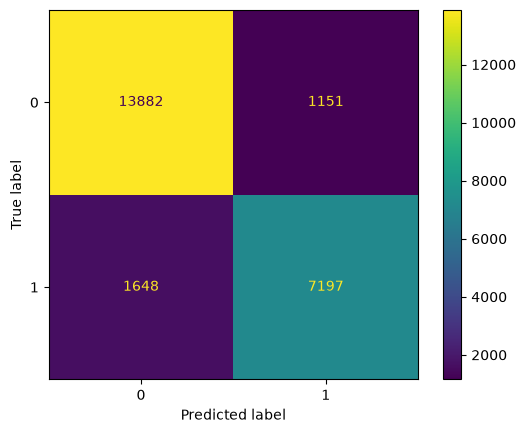

In [ ]:
print("Classification Report")
print("-" * 60)
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print("-" * 60)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

El informe de clasificación muestra un rendimiento equilibrado para ambas clases. La clase correspondiente a las reservas no canceladas presenta valores ligeramente superiores de precisión y recall, mientras que la clase de las reservas canceladas mantiene también un buen nivel de rendimiento, alcanzando un F1-Score de 0.84. Estos resultados indican que el modelo es capaz de identificar correctamente ambas clases sin mostrar un sesgo significativo hacia ninguna de ellas.

La matriz de confusión confirma el buen comportamiento del modelo, mostrando un elevado número de predicciones correctas tanto para las reservas canceladas como para las no canceladas. Aunque siguen existiendo algunos falsos positivos y falsos negativos, su proporción es reducida en comparación con el número total de observaciones. En consecuencia, el modelo presenta una capacidad de clasificación adecuada para este problema, ofreciendo un equilibrio satisfactorio entre precisión y sensibilidad.

### Curva ROC

Con el objetivo de visualizar gráficamente la capacidad discriminativa del modelo, se representa la curva ROC (Receiver Operating Characteristic). Esta curva muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos para los distintos umbrales de clasificación. Cuanto más próxima se encuentre la curva a la esquina superior izquierda, mejor será la capacidad del modelo para diferenciar entre ambas clases.

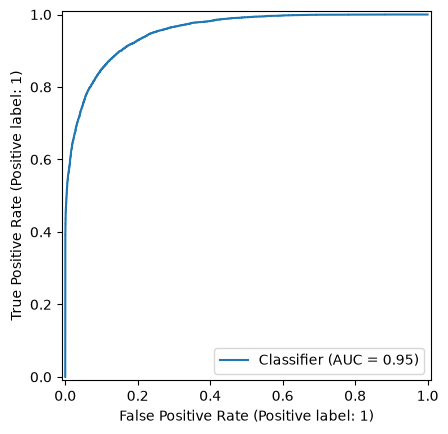

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob);

La curva ROC obtenida se aproxima claramente a la esquina superior izquierda del gráfico, lo que indica una elevada capacidad del modelo para distinguir entre reservas canceladas y no canceladas. Este comportamiento queda respaldado por el valor de ROC AUC obtenido (≈0.953), confirmando que el modelo presenta un excelente rendimiento y una buena capacidad de generalización sobre datos no vistos durante el entrenamiento.

### Feature importances

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train_prep.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
49,deposit_type_Non Refund,0.596753
48,deposit_type_No Deposit,0.121308
12,required_car_parking_spaces,0.052494
50,deposit_type_Refundable,0.048939
37,market_segment_Online TA,0.016590
7,previous_cancellations,0.014951
46,customer_type_Transient,0.009176
94,country_PRT,0.008257
36,market_segment_Offline TA/TO,0.005895
83,country_DEU,0.004042


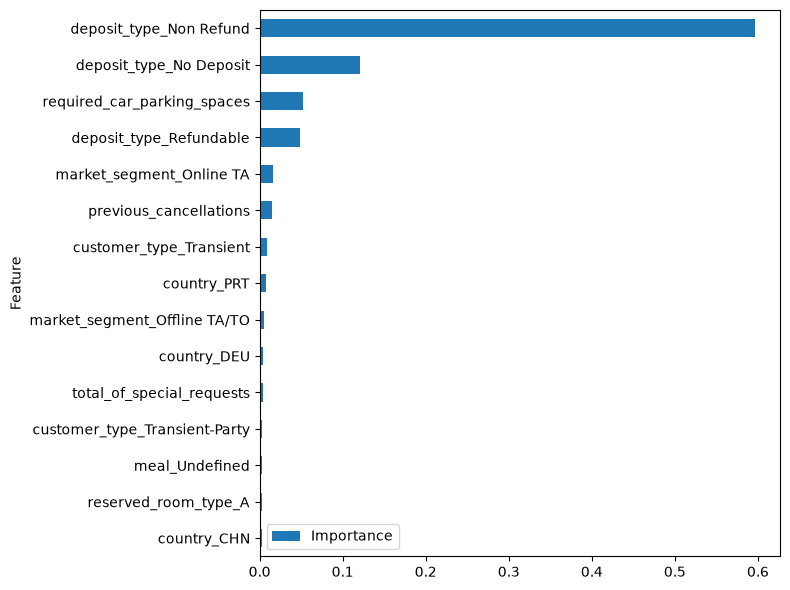

In [ ]:
importance.head(15).plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

El análisis de importancia de variables muestra que el tipo de depósito constituye, con diferencia, el factor más influyente en las predicciones del modelo. En particular, la variable `deposit_type_Non Refund` presenta una importancia significativamente superior al resto, indicando que las reservas con depósitos no reembolsables tienen un peso determinante en la predicción de cancelaciones. Tras ella, aunque con una contribución considerablemente menor, destacan variables como `deposit_type_No Deposit`, `required_car_parking_spaces`, `previous_cancellations` y el segmento de mercado (`market_segment`). En conjunto, estos resultados permiten identificar los factores que más influyen en la toma de decisiones del modelo y aportan una mayor interpretabilidad sobre el proceso de predicción.

# Puesta en marcha del modelo con datos nuevos

### Creación del nuevo registro

Se simula una nueva reserva hotelera utilizando las variables originales del conjunto de datos, ya que este es el formato con el que se recibirán los nuevos registros en un entorno real. Posteriormente, dicha reserva será transformada mediante el pipeline de preprocesado antes de ser utilizada por el modelo para generar la predicción.

In [ ]:
nueva_reserva = pd.DataFrame({
    "hotel": ["City Hotel"],
    "lead_time": [180],
    "arrival_date_year": [2017],
    "arrival_date_month": ["August"],
    "arrival_date_week_number": [34],
    "arrival_date_day_of_month": [20],
    "stays_in_weekend_nights": [2],
    "stays_in_week_nights": [5],
    "adults": [2],
    "children": [1],
    "babies": [0],
    "meal": ["BB"],
    "country": ["ESP"],
    "market_segment": ["Online TA"],
    "distribution_channel": ["TA/TO"],
    "is_repeated_guest": [0],
    "previous_cancellations": [0],
    "previous_bookings_not_canceled": [0],
    "reserved_room_type": ["A"],
    "assigned_room_type": ["A"],
    "booking_changes": [0],
    "deposit_type": ["No Deposit"],
    "agent": [240],
    "company": [np.nan],
    "days_in_waiting_list": [0],
    "customer_type": ["Transient"],
    "adr": [140.0],
    "required_car_parking_spaces": [1],
    "total_of_special_requests": [2],
    "reservation_status": ["Check-Out"],          # se eliminará en el pipeline
    "reservation_status_date": ["2017-08-20"]     # se eliminará en el pipeline
})

### Aplicación del pipeline completo para transformar los nuevos datos

In [ ]:
full_pipeline = joblib.load("src/models/full_pipeline.pkl")

In [ ]:
nueva_reserva_prep = full_pipeline.transform(nueva_reserva)

pred = best_xgb.predict(nueva_reserva_prep)[0]
prob = best_xgb.predict_proba(nueva_reserva_prep)[0, 1]

In [ ]:
print("Predicción de la nueva reserva")
print("-" * 40)

if pred == 1:
    print("Resultado: La reserva será cancelada.")
else:
    print("Resultado: La reserva no será cancelada.")

print(f"\nProbabilidad de cancelación: {prob:.2%}")
print(f"Probabilidad de no cancelación: {(1-prob):.2%}")

Predicción de la nueva reserva
----------------------------------------
Resultado: La reserva no será cancelada.

Probabilidad de cancelación: 0.12%
Probabilidad de no cancelación: 99.88%


Como ejemplo de aplicación práctica, se realiza una predicción sobre una nueva reserva hotelera simulada. Tras aplicar el mismo pipeline de preprocesado utilizado durante el entrenamiento, el modelo estima tanto la clase predicha como la probabilidad asociada a una posible cancelación. En este caso, el modelo predice que la reserva no será cancelada, asignándole una probabilidad de cancelación del 0.12 % y una probabilidad del 99.88 % de que la reserva se mantenga. Este ejemplo ilustra cómo el modelo puede emplearse para estimar el riesgo de cancelación de futuras reservas y servir de apoyo en la toma de decisiones dentro del ámbito hotelero.

# Conclusiones finales

A lo largo de este proyecto se ha desarrollado un modelo de Machine Learning capaz de predecir la cancelación de reservas hoteleras a partir de la información disponible en el momento de la reserva. Para ello, se ha seguido un flujo de trabajo completo que abarca desde el análisis exploratorio de los datos y el preprocesado, hasta el entrenamiento, la optimización y la evaluación final del modelo.

Tras comparar distintos algoritmos de clasificación, XGBoost fue el modelo que obtuvo el mejor rendimiento global, superando al resto de candidatos en todas las métricas evaluadas. Posteriormente, la optimización mediante `RandomizedSearchCV` y `GridSearchCV` permitió mejorar ligeramente sus prestaciones, alcanzando un ROC AUC cercano a 0.953 y manteniendo un rendimiento sólido sobre el conjunto de prueba, lo que demuestra una buena capacidad de generalización.

El análisis de la importancia de variables permitió identificar los factores con mayor influencia en la predicción, destacando especialmente el tipo de depósito (`deposit_type`), junto con otras variables relacionadas con el comportamiento histórico del cliente y las características de la reserva. Este análisis aporta una mayor interpretabilidad al modelo y facilita la comprensión de las decisiones tomadas por el algoritmo.

Finalmente, se ha simulado la predicción de una nueva reserva utilizando el pipeline completo de preprocesado y el modelo optimizado, reproduciendo el flujo que seguiría una aplicación real. De este modo, el proyecto no solo demuestra la capacidad predictiva del modelo, sino también su posible integración en un entorno de producción como herramienta de apoyo para la gestión hotelera y la toma de decisiones estratégicas.